# XGBoost Training Notebook

This notebook follows the same workflow as the training script.
The only model-specific difference is the classifier.

## Reading Guide

This notebook is long because it preserves the full search history, not because the final
pipeline is complex. If you only want the result:

- **Final model & why it was chosen:** [Final Selected XGBoost Model](#Final-Selected-XGBoost-Model)
  (near the end), which explains what was kept, what was tried and rejected, and why.
- **Feature importance:** [Explainable AI: SHAP Feature Importance](#Explainable-AI:-SHAP-Feature-Importance),
  directly below it.
- **Cross-model comparison:** [Final Model Comparison Across All Models](#Final-Model-Comparison-Across-All-Models),
  at the very end.

**Winning lineage**, in the order these levers were found (each section below is titled with
its Experiment/Improvement number):
Winsorization (Improvement 3) -> Optuna-tuned hyperparameters (Experiment 19) ->
`num_parallel_tree=3` (Experiment 15) -> `tree_method="hist", max_bin=16` (Experiment 23) ->
combined and locked in as the [Final Selected XGBoost Model](#Final-Selected-XGBoost-Model).

Everything between the "XGBoost Ablation Study" section and the final model is a **sequential
experiment log** (Experiments 7-28): each cell builds on results/variables from earlier cells
in the log, so they are not independent and are kept in run order. Most of them tried something
that did *not* improve on the current best - that is expected and is itself the evidence the
final configuration isn't a lucky fluke.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from xgboost import XGBClassifier

ROOT_DIR = Path.cwd().resolve().parent.parent
PYTHON_DIR = ROOT_DIR / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

from common import (  # noqa: E402
    CLASS_ORDER,
    coerce_feature_types,
    evaluate_predictions,
    load_tabular_file,
    build_preprocessor,
    split_feature_columns,
    infer_numeric_like_columns,
    standardize_columns,
    find_column,
    clean_rating_label,
    create_rating_group,
    IDENTIFIER_ALIASES,
    TARGET_ALIASES,
)

# Auto-detect the first CSV or Excel file in the data/ directory.
_data_dir = ROOT_DIR / "data"
_candidates = sorted(
    list(_data_dir.glob("*.csv")) + list(_data_dir.glob("*.xlsx")) + list(_data_dir.glob("*.xls"))
)
if not _candidates:
    raise FileNotFoundError(
        f"No CSV or Excel file found in {_data_dir}. ",
        "Please place your dataset there and re-run this cell.",
    )
DATA_PATH = _candidates[0]
print(f"Using dataset: {DATA_PATH}")
print("Imports ready")

Using dataset: C:\Users\24042662\Desktop\C300\CreditSight\data\set A corporate_rating.csv
Imports ready


In [2]:
# Step 1: Load the dataset.
raw_df = load_tabular_file(str(DATA_PATH))
df = standardize_columns(raw_df)
print(df.shape)
df.head()

(2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [3]:
# Step 2: Check missing values and duplicates.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())
print(missing_values[missing_values > 0])
print("Duplicate rows:", duplicate_rows)

Series([], dtype: int64)
Duplicate rows: 0


In [4]:
# Step 3: Create the RatingGroup target.
rating_column = find_column(df, TARGET_ALIASES)
if rating_column is None:
    raise ValueError("No rating column found in the dataset.")

working_df = df.copy()
working_df[rating_column] = working_df[rating_column].apply(clean_rating_label)
working_df["RatingGroup"] = working_df[rating_column].apply(create_rating_group)
working_df = working_df.dropna(subset=["RatingGroup"]).copy()

identifier_columns = []
for alias in IDENTIFIER_ALIASES:
    found = find_column(working_df, [alias])
    if found and found not in identifier_columns:
        identifier_columns.append(found)

if rating_column not in identifier_columns:
    identifier_columns.append(rating_column)

working_df = working_df.drop(columns=identifier_columns, errors="ignore")
working_df = infer_numeric_like_columns(working_df, exclude_columns=["RatingGroup"])
print(working_df["RatingGroup"].value_counts())

RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [5]:
# Step 4: Select features and prepare the training data.
feature_columns = [column for column in working_df.columns if column != "RatingGroup"]
numeric_columns, categorical_columns = split_feature_columns(working_df, "RatingGroup", [])
X = working_df[feature_columns].copy()
X = coerce_feature_types(X, numeric_columns, categorical_columns)
y = working_df["RatingGroup"].copy()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']
Categorical columns: ['Sector']


In [6]:
# Step 5: Split the dataset and train the model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
pipeline.fit(X_train, y_train)
print("Model trained")

Model trained


In [7]:
# Step 6: Evaluate the trained model.
y_pred = pipeline.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred.astype(int))
metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)
print(metrics["accuracy"])
print(metrics["classification_report_text"])


0.6633825944170771
                 precision    recall  f1-score   support

Investment-High       0.66      0.64      0.65       148
 Investment-Low       0.62      0.56      0.58       201
    Speculative       0.71      0.82      0.76       238
     Distressed       0.43      0.14      0.21        22

       accuracy                           0.66       609
      macro avg       0.60      0.54      0.55       609
   weighted avg       0.65      0.66      0.65       609



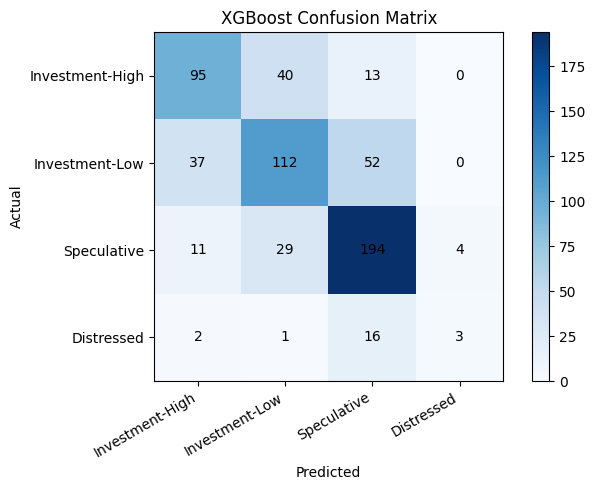

In [8]:
# Step 7: Show the confusion matrix.
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## XGBoost Ablation Study

Every section below starts from the same untouched `X_train`, `X_test`, `y_train`, `y_test`,
and preprocessing definition (`build_preprocessor`) created in Step 5 above - none of them
are refit or modified. Each section changes exactly one variable relative to the baseline
`XGBClassifier(random_state=42, eval_metric="mlogloss")` trained in Step 5/6, so results can
be attributed to that single change. Running totals are kept in `ablation_records`, and the
final section consolidates everything into one comparison table. This section does not
touch `pipeline`, `metrics`, or any other variable the Min-Max Normalization / Experiment 7 /
Experiment 8 / SHAP sections below rely on.


### 1. Baseline

Untouched `X_train`/`X_test` split, default `build_preprocessor`, default `XGBClassifier`
hyperparameters. No tuning, no class-imbalance handling, no early stopping. Every later
section in this ablation study is compared back to this.


In [9]:
# Section 1: Baseline
import time

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score


def per_class_f1(y_true_labels, y_pred_labels, class_order):
    scores = f1_score(y_true_labels, y_pred_labels, labels=class_order, average=None, zero_division=0)
    return {label: float(score) for label, score in zip(class_order, scores)}


def make_ablation_row(step_name, metrics_dict, y_true_labels, y_pred_labels, notes=""):
    row = {
        "Step": step_name,
        "Accuracy": metrics_dict["accuracy"],
        "Macro F1": metrics_dict["macro_f1"],
        "Weighted F1": metrics_dict["weighted_f1"],
    }
    row.update(per_class_f1(y_true_labels, y_pred_labels, CLASS_ORDER))
    row["Notes"] = notes
    return row


# Baseline is exactly the model already trained in Step 5/6 above - XGBClassifier(random_state=42,
# eval_metric="mlogloss"), all other params default. Reused as-is (not refit); copied into new names
# so the Min-Max/Experiment cells below, which read "metrics" and "pipeline" directly, are unaffected.
ablation_baseline_metrics = metrics
ablation_baseline_pred_labels = y_pred_labels

ablation_records = []
ablation_results = {}

ablation_records.append(
    make_ablation_row(
        "1. Baseline",
        ablation_baseline_metrics,
        y_test_labels,
        ablation_baseline_pred_labels,
        notes="Fixed reference point for every later comparison. Untouched XGBClassifier defaults.",
    )
)
ablation_results["Baseline"] = ablation_baseline_metrics

pd.DataFrame(ablation_records)


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...


### 2. Hyperparameter tuning only

`RandomizedSearchCV` over `n_estimators`, `learning_rate`, `max_depth`, `subsample`,
`colsample_bytree`. No early stopping, no
`sample_weight`, no monotonic constraints. Searched on `X_train` only (5-fold CV inside
the search); scored once on the untouched `X_test`.

> **Note:** This search only exists to measure HPO's isolated contribution within the
> ablation study above - it uses a different search method and parameter space than the
> final tuning pass in **Experiment 7 / Experiment 8** later in the notebook. Its
> `best_params_` should not be read as the model's final chosen hyperparameters; those
> come from Experiment 7/8.


In [10]:
# Section 2: Hyperparameter tuning only
hpo_param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
}

ablation_hpo_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
        ]
    ),
    param_distributions=hpo_param_distributions,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    refit=True,
)
ablation_hpo_search.fit(X_train, y_train)

hpo_pred = ablation_hpo_search.best_estimator_.predict(X_test)
hpo_pred_labels = label_encoder.inverse_transform(hpo_pred.astype(int))
hpo_metrics = evaluate_predictions(y_test_labels, hpo_pred_labels, CLASS_ORDER)

print("Best hyperparameters found:")
print(ablation_hpo_search.best_params_)
print(f"Best cross-validation accuracy: {ablation_hpo_search.best_score_:.4f}")

ablation_records.append(
    make_ablation_row(
        "2. Hyperparameter tuning only",
        hpo_metrics,
        y_test_labels,
        hpo_pred_labels,
        notes=f"RandomizedSearchCV (n_iter=40, cv=5) best params: {ablation_hpo_search.best_params_}",
    )
)
ablation_results["Hyperparameter tuning only"] = hpo_metrics

pd.DataFrame(ablation_records)


Best hyperparameters found:
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best cross-validation accuracy: 0.6648


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,"RandomizedSearchCV (n_iter=40, cv=5) best para..."


### 3. Class imbalance handling only

Baseline hyperparameters, unchanged, plus `sample_weight=compute_sample_weight("balanced",
y_train)` passed into `fit`. Nothing else changes from the baseline.


In [11]:
# Section 3: Class imbalance handling only
imbalance_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
imbalance_sample_weight = compute_sample_weight("balanced", y_train)
imbalance_pipeline.fit(X_train, y_train, model__sample_weight=imbalance_sample_weight)

imbalance_pred = imbalance_pipeline.predict(X_test)
imbalance_pred_labels = label_encoder.inverse_transform(imbalance_pred.astype(int))
imbalance_metrics = evaluate_predictions(y_test_labels, imbalance_pred_labels, CLASS_ORDER)

ablation_records.append(
    make_ablation_row(
        "3. Class imbalance handling only",
        imbalance_metrics,
        y_test_labels,
        imbalance_pred_labels,
        notes="Baseline hyperparameters + sample_weight=compute_sample_weight('balanced', y_train).",
    )
)
ablation_results["Class imbalance handling only"] = imbalance_metrics

pd.DataFrame(ablation_records)


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...


### 4. Early stopping only

Baseline hyperparameters + a validation slice carved out of `X_train` only (15%, stratified;
`X_test` and the original `X_train` are untouched) + `early_stopping_rounds=20`, with
`n_estimators=1000` so early stopping has room to actually decide the round count.

The correct comparison point is **not** the Step-1 baseline (which caps at
`n_estimators=100`) but a same-`n_estimators=1000` variant *without* early stopping - that
isolates "did stopping early help" from "did more rounds help". Both are computed below.


In [12]:
# Section 4: Early stopping only
# 4a. Fair comparison point: baseline hyperparameters, generously high n_estimators, no early stopping.
high_estimators_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss", n_estimators=1000)),
    ]
)
high_estimators_pipeline.fit(X_train, y_train)
high_estimators_pred = high_estimators_pipeline.predict(X_test)
high_estimators_pred_labels = label_encoder.inverse_transform(high_estimators_pred.astype(int))
high_estimators_metrics = evaluate_predictions(y_test_labels, high_estimators_pred_labels, CLASS_ORDER)

print("4a. High n_estimators (no early stopping) - comparison point only, not in the final table:")
print(f"    Accuracy {high_estimators_metrics['accuracy']:.4f}, Macro F1 {high_estimators_metrics['macro_f1']:.4f}")

# 4b. Early stopping against a validation slice carved out of X_train only.
X_fit_es, X_val_es, y_fit_es, y_val_es = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train,
)

early_stop_preprocessor = build_preprocessor(numeric_columns, categorical_columns)
X_fit_es_transformed = early_stop_preprocessor.fit_transform(X_fit_es)
X_val_es_transformed = early_stop_preprocessor.transform(X_val_es)

early_stop_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    n_estimators=1000,
    early_stopping_rounds=20,
)
early_stop_model.fit(
    X_fit_es_transformed,
    y_fit_es,
    eval_set=[(X_val_es_transformed, y_val_es)],
    verbose=False,
)

early_stop_pipeline = Pipeline(steps=[("preprocessor", early_stop_preprocessor), ("model", early_stop_model)])
early_stop_pred = early_stop_pipeline.predict(X_test)
early_stop_pred_labels = label_encoder.inverse_transform(early_stop_pred.astype(int))
early_stop_metrics = evaluate_predictions(y_test_labels, early_stop_pred_labels, CLASS_ORDER)

print(f"Early stopping halted at iteration: {early_stop_model.best_iteration}")
vs_4a = (
    "improved on 4a"
    if (early_stop_metrics["accuracy"] > high_estimators_metrics["accuracy"]
        or early_stop_metrics["macro_f1"] > high_estimators_metrics["macro_f1"])
    else "did not improve on 4a"
)
print(f"4b vs 4a: {vs_4a}")

ablation_records.append(
    make_ablation_row(
        "4. Early stopping only",
        early_stop_metrics,
        y_test_labels,
        early_stop_pred_labels,
        notes=(
            f"Baseline hyperparameters + 15% validation slice of X_train + early_stopping_rounds=20, "
            f"n_estimators=1000. Stopped at iteration {early_stop_model.best_iteration}. Fair comparison "
            f"point is n_estimators=1000 without early stopping (accuracy {high_estimators_metrics['accuracy']:.4f}, "
            f"macro F1 {high_estimators_metrics['macro_f1']:.4f}), not the Step-1 baseline: {vs_4a}."
        ),
    )
)
ablation_results["Early stopping only"] = early_stop_metrics

pd.DataFrame(ablation_records)


4a. High n_estimators (no early stopping) - comparison point only, not in the final table:
    Accuracy 0.6798, Macro F1 0.5778
Early stopping halted at iteration: 20
4b vs 4a: did not improve on 4a


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.541995,0.633683,0.635452,0.568528,0.724000,0.240000,Baseline hyperparameters + 15% validation slic...


### 5. `tree_method="hist"` only

Baseline hyperparameters + `tree_method="hist"`. This is framed as a speed/approximation
comparison, not an accuracy one: XGBoost 3.0's `hist` split-finding is close to exact, so
the expected accuracy delta is small (roughly &plusmn;0.5%), and its real value is letting a
much larger hyperparameter search finish in the same wall-clock budget. Wall-clock training
time is reported alongside accuracy.


In [13]:
# Section 5: tree_method="hist" only
ablation_baseline_retrain_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
baseline_train_start = time.perf_counter()
ablation_baseline_retrain_pipeline.fit(X_train, y_train)
baseline_train_seconds = time.perf_counter() - baseline_train_start

hist_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss", tree_method="hist")),
    ]
)
hist_train_start = time.perf_counter()
hist_pipeline.fit(X_train, y_train)
hist_train_seconds = time.perf_counter() - hist_train_start

hist_pred = hist_pipeline.predict(X_test)
hist_pred_labels = label_encoder.inverse_transform(hist_pred.astype(int))
hist_metrics = evaluate_predictions(y_test_labels, hist_pred_labels, CLASS_ORDER)

accuracy_delta = hist_metrics["accuracy"] - ablation_baseline_metrics["accuracy"]
print(f"Baseline (default tree_method) training time: {baseline_train_seconds:.3f}s")
print(f"tree_method='hist' training time:              {hist_train_seconds:.3f}s")
print(f"Accuracy delta vs baseline: {accuracy_delta:+.4f}")

ablation_records.append(
    make_ablation_row(
        "5. tree_method='hist' only",
        hist_metrics,
        y_test_labels,
        hist_pred_labels,
        notes=(
            f"Speed/approximation comparison, not an accuracy one. Training time {hist_train_seconds:.3f}s "
            f"vs {baseline_train_seconds:.3f}s baseline (accuracy delta {accuracy_delta:+.4f}). Value is "
            "enabling a larger hyperparameter search in the same time budget, not raw accuracy."
        ),
    )
)
ablation_results["tree_method='hist' only"] = hist_metrics

pd.DataFrame(ablation_records)


Baseline (default tree_method) training time: 0.347s
tree_method='hist' training time:              0.323s
Accuracy delta vs baseline: +0.0000


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.541995,0.633683,0.635452,0.568528,0.724000,0.240000,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,"Speed/approximation comparison, not an accurac..."


### 6. Scoring objective: `scoring="f1_macro"` only

Identical setup to Section 2 (same `RandomizedSearchCV` grid, `n_iter=40`, 5-fold
`StratifiedKFold`, same Step-1 baseline `X_train`/`X_test`) — the only variable changed is the
search's `scoring` argument, from `"accuracy"` to `"f1_macro"`. This isolates the effect of
the search objective itself: does *what the search optimizes for* change the outcome,
independent of every other choice? This replaces the two ad hoc "Improvement 2" diagnostic
cells that previously tested this same idea against Experiment 7/8's own separately-tuned
baselines instead of the shared Step-1 baseline used by every other section here.


In [14]:
# Section 6: scoring="f1_macro" only
f1_hpo_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
        ]
    ),
    param_distributions=hpo_param_distributions,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
    refit=True,
)
f1_hpo_search.fit(X_train, y_train)

f1_hpo_pred = f1_hpo_search.best_estimator_.predict(X_test)
f1_hpo_pred_labels = label_encoder.inverse_transform(f1_hpo_pred.astype(int))
f1_hpo_metrics = evaluate_predictions(y_test_labels, f1_hpo_pred_labels, CLASS_ORDER)

print("Best hyperparameters found (f1_macro-scored):")
print(f1_hpo_search.best_params_)
print(f"Best cross-validation macro F1: {f1_hpo_search.best_score_:.4f}")

ablation_records.append(
    make_ablation_row(
        "6. Scoring objective: f1_macro-scored tuning only",
        f1_hpo_metrics,
        y_test_labels,
        f1_hpo_pred_labels,
        notes=(
            "Identical to Section 2 (same RandomizedSearchCV grid, n_iter=40, cv=5) except "
            "scoring='f1_macro' instead of 'accuracy'. Isolates the effect of the search "
            f"objective itself, holding everything else fixed. Best params: {f1_hpo_search.best_params_}"
        ),
    )
)
ablation_results["Scoring objective: f1_macro-scored tuning only"] = f1_hpo_metrics

pd.DataFrame(ablation_records)


Best hyperparameters found (f1_macro-scored):
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best cross-validation macro F1: 0.5698


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.541995,0.633683,0.635452,0.568528,0.724000,0.240000,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,"Speed/approximation comparison, not an accurac..."
5,6. Scoring objective: f1_macro-scored tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,Identical to Section 2 (same RandomizedSearchC...


### 7. Final combination

Combines only the changes from steps 2-5 that individually beat the Step-1 baseline on
accuracy or macro F1. The combination is trained once, cleanly, from the same untouched
baseline setup. If the combined result underperforms the best individual step, that is an
interaction effect worth calling out explicitly in the writeup - it means the changes did
not stack additively.


In [15]:
# Section 7: Final combination
def improved_over_baseline(name):
    candidate = ablation_results[name]
    return (candidate["accuracy"] > ablation_baseline_metrics["accuracy"]) or (candidate["macro_f1"] > ablation_baseline_metrics["macro_f1"])

use_hpo = improved_over_baseline("Hyperparameter tuning only")
use_imbalance = improved_over_baseline("Class imbalance handling only")
use_early_stop = improved_over_baseline("Early stopping only")
use_hist = improved_over_baseline("tree_method='hist' only")

print("Steps flagged for inclusion (must beat the Step-1 baseline on accuracy or macro F1):")
print(f"  Hyperparameter tuning : {use_hpo}")
print(f"  Class imbalance       : {use_imbalance}")
print(f"  Early stopping        : {use_early_stop}")
print(f"  tree_method='hist'    : {use_hist}")

combo_model_params = {"random_state": 42, "eval_metric": "mlogloss"}
combo_notes_parts = []

if use_hpo:
    combo_model_params.update({key.split("__", 1)[1]: value for key, value in ablation_hpo_search.best_params_.items()})
    combo_notes_parts.append("HPO-search hyperparameters")
if use_hist:
    combo_model_params["tree_method"] = "hist"
    combo_notes_parts.append("tree_method='hist'")

combo_preprocessor = build_preprocessor(numeric_columns, categorical_columns)

if use_early_stop:
    combo_model_params.setdefault("n_estimators", 1000)
    combo_model_params["early_stopping_rounds"] = 20
    combo_notes_parts.append("early stopping")

    X_fit_combo, X_val_combo, y_fit_combo, y_val_combo = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train,
    )
    X_fit_combo_t = combo_preprocessor.fit_transform(X_fit_combo)
    X_val_combo_t = combo_preprocessor.transform(X_val_combo)

    combo_model = XGBClassifier(**combo_model_params)
    combo_fit_kwargs = {"eval_set": [(X_val_combo_t, y_val_combo)], "verbose": False}
    if use_imbalance:
        combo_fit_kwargs["sample_weight"] = compute_sample_weight("balanced", y_fit_combo)
        combo_notes_parts.append("class-balanced sample_weight")
    combo_model.fit(X_fit_combo_t, y_fit_combo, **combo_fit_kwargs)
else:
    combo_model = XGBClassifier(**combo_model_params)
    combo_preprocessor.fit(X_train)
    X_train_combo_t = combo_preprocessor.transform(X_train)
    combo_fit_kwargs = {}
    if use_imbalance:
        combo_fit_kwargs["sample_weight"] = compute_sample_weight("balanced", y_train)
        combo_notes_parts.append("class-balanced sample_weight")
    combo_model.fit(X_train_combo_t, y_train, **combo_fit_kwargs)

combo_pipeline = Pipeline(steps=[("preprocessor", combo_preprocessor), ("model", combo_model)])
combo_pred = combo_pipeline.predict(X_test)
combo_pred_labels = label_encoder.inverse_transform(combo_pred.astype(int))
combo_metrics = evaluate_predictions(y_test_labels, combo_pred_labels, CLASS_ORDER)

if not combo_notes_parts:
    combo_notes_parts.append("no individual step beat baseline, so this combination equals the untouched baseline")

candidate_names = ["Hyperparameter tuning only", "Class imbalance handling only", "Early stopping only", "tree_method='hist' only"]
best_individual_accuracy = max(ablation_results[name]["accuracy"] for name in candidate_names)
best_individual_macro_f1 = max(ablation_results[name]["macro_f1"] for name in candidate_names)

interaction_flag = (
    combo_metrics["accuracy"] < best_individual_accuracy
    or combo_metrics["macro_f1"] < best_individual_macro_f1
)

if interaction_flag:
    combo_notes_parts.append(
        f"INTERACTION EFFECT: combination (accuracy {combo_metrics['accuracy']:.4f}, macro F1 "
        f"{combo_metrics['macro_f1']:.4f}) underperforms the best individual step (accuracy "
        f"{best_individual_accuracy:.4f}, macro F1 {best_individual_macro_f1:.4f}) - the changes did not "
        "stack additively."
    )

print("Combined hyperparameters used:", combo_model_params)
print("Steps included:", ", ".join(combo_notes_parts))
if interaction_flag:
    print("\n*** Interaction effect detected: see Notes in the summary table. ***")

ablation_records.append(
    make_ablation_row(
        "7. Final combination",
        combo_metrics,
        y_test_labels,
        combo_pred_labels,
        notes="; ".join(combo_notes_parts),
    )
)
ablation_results["Final combination"] = combo_metrics

pd.DataFrame(ablation_records)


Steps flagged for inclusion (must beat the Step-1 baseline on accuracy or macro F1):
  Hyperparameter tuning : True
  Class imbalance       : True
  Early stopping        : False
  tree_method='hist'    : False


Combined hyperparameters used: {'random_state': 42, 'eval_metric': 'mlogloss', 'subsample': 0.7, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Steps included: HPO-search hyperparameters, class-balanced sample_weight


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.673235,0.589030,0.669644,0.686667,0.619792,0.733871,0.315789,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.642036,0.541995,0.633683,0.635452,0.568528,0.724000,0.240000,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.663383,0.549138,0.653675,0.648464,0.584856,0.756335,0.206897,"Speed/approximation comparison, not an accurac..."
5,6. Scoring objective: f1_macro-scored tuning only,0.679803,0.580036,0.671141,0.652632,0.622108,0.759690,0.285714,Identical to Section 2 (same RandomizedSearchC...
6,7. Final combination,0.683087,0.606343,0.677327,0.677852,0.614583,0.757937,0.375000,HPO-search hyperparameters; class-balanced sam...


### 8. Summary table

Consolidated ablation table - paste directly into the report.


In [16]:
# Section 8: Summary table
ablation_summary_df = pd.DataFrame(ablation_records)

ordered_columns = ["Step", "Accuracy", "Macro F1", "Weighted F1"] + CLASS_ORDER + ["Notes"]
ablation_summary_df = ablation_summary_df[ordered_columns]

numeric_summary_columns = ["Accuracy", "Macro F1", "Weighted F1"] + CLASS_ORDER
ablation_summary_df[numeric_summary_columns] = ablation_summary_df[numeric_summary_columns].round(4)

output_path = ROOT_DIR / "outputs" / "xgboost_ablation_summary.csv"
ablation_summary_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

ablation_summary_df


Saved to C:\Users\24042662\Desktop\C300\CreditSight\outputs\xgboost_ablation_summary.csv


,Step,Accuracy,Macro F1,Weighted F1,Investment-High,Investment-Low,Speculative,Distressed,Notes
0,1. Baseline,0.6634,0.5491,0.6537,0.6485,0.5849,0.7563,0.2069,Fixed reference point for every later comparis...
1,2. Hyperparameter tuning only,0.6798,0.5800,0.6711,0.6526,0.6221,0.7597,0.2857,"RandomizedSearchCV (n_iter=40, cv=5) best para..."
2,3. Class imbalance handling only,0.6732,0.5890,0.6696,0.6867,0.6198,0.7339,0.3158,Baseline hyperparameters + sample_weight=compu...
3,4. Early stopping only,0.6420,0.5420,0.6337,0.6355,0.5685,0.7240,0.2400,Baseline hyperparameters + 15% validation slic...
4,5. tree_method='hist' only,0.6634,0.5491,0.6537,0.6485,0.5849,0.7563,0.2069,"Speed/approximation comparison, not an accurac..."
5,6. Scoring objective: f1_macro-scored tuning only,0.6798,0.5800,0.6711,0.6526,0.6221,0.7597,0.2857,Identical to Section 2 (same RandomizedSearchC...
6,7. Final combination,0.6831,0.6063,0.6773,0.6779,0.6146,0.7579,0.3750,HPO-search hyperparameters; class-balanced sam...


## Min-Max Normalization

Min-Max normalization places numeric values within a fixed range, usually 0 to 1. The scaler is fit on `X_train` only, then applied to both `X_train` and `X_test`.


             Scenario  Accuracy  Weighted F1  Macro F1
             Baseline  0.663383     0.653675  0.549138
Min-Max Normalization  0.674877     0.665645  0.591506
                 precision    recall  f1-score   support

Investment-High       0.67      0.70      0.68       148
 Investment-Low       0.64      0.54      0.59       201
    Speculative       0.69      0.82      0.75       238
     Distressed       0.71      0.23      0.34        22

       accuracy                           0.67       609
      macro avg       0.68      0.57      0.59       609
   weighted avg       0.67      0.67      0.67       609



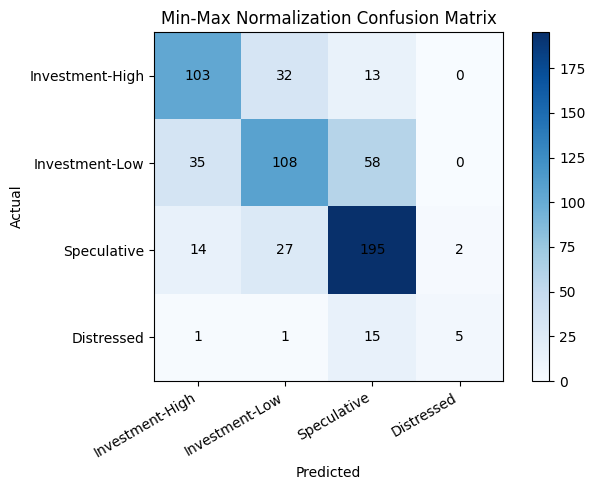

In [17]:
baseline_metrics = dict(metrics)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(
    X.copy(),
    y_encoded.copy(),
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot),
    ]
)

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, numeric_columns),
        ("categorical", categorical_pipe, categorical_columns),
    ],
    remainder="drop",
)

minmax_pipeline = Pipeline(
    steps=[
        ("preprocessor", minmax_preprocessor),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
minmax_pipeline.fit(X_train_minmax, y_train_minmax)

minmax_pred = minmax_pipeline.predict(X_test_minmax)
y_test_labels = label_encoder.inverse_transform(y_test_minmax)
y_pred_labels = label_encoder.inverse_transform(minmax_pred.astype(int))
minmax_metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)

comparison_table = pd.DataFrame(
    [
        {
            "Scenario": "Baseline",
            "Accuracy": baseline_metrics["accuracy"],
            "Weighted F1": baseline_metrics["weighted_f1"],
            "Macro F1": baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Min-Max Normalization",
            "Accuracy": minmax_metrics["accuracy"],
            "Weighted F1": minmax_metrics["weighted_f1"],
            "Macro F1": minmax_metrics["macro_f1"],
        },
    ]
)

print(comparison_table.to_string(index=False))
print(minmax_metrics["classification_report_text"])

cm = np.array(minmax_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Min-Max Normalization Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## Improvement 3: Winsorization of Financial Ratio Outliers

**Weakness identified.** Several ratio features (e.g. `debtEquityRatio`,
`enterpriseValueMultiple`, `freeCashFlowPerShare`) are computed by dividing by
denominators (equity, EBITDA, shares outstanding) that can be near zero for a handful of
issuers, producing a small number of extreme-magnitude values. No outlier handling is applied
anywhere in the current pipeline (median imputation only addresses missing values, not
extremes, and none exist in this dataset - the ratios are simply unbounded).

**Why this hurts XGBoost specifically.** Gradient boosting fits each new tree to the
gradient/hessian of the loss from the *current* ensemble. A handful of extreme-valued rows can
receive disproportionately large gradients relative to the rest of the class they belong to,
pulling early-round splits toward accommodating those outliers rather than the general
pattern for that class. With Distressed already at only 72 rows total (22 in the test split),
a single extreme row is a much larger fraction of that class's signal than it would be for
Investment-Low or Speculative - so this risk is concentrated exactly where the model is
already weakest. Decision Tree/Random Forest are comparatively less exposed since each split
only affects one branch of one (bagged) tree, not the shared sequential loss.

**Solution.** Add a `Winsorizer` transformer that clips each numeric feature to the
[1st, 99th] percentile range learned from `X_train` only (never `X_test`), inserted into the
numeric branch of the preprocessing `ColumnTransformer` after imputation. Compared against the
untouched Step 5/6 baseline, using the same `random_state=42` train/test partition and the same
default `XGBClassifier(random_state=42, eval_metric="mlogloss")` - isolating winsorization as
the single changed variable, in the same style as the Min-Max Normalization section above.

**Expected impact:** Low-Medium overall, but potentially concentrated exactly on Distressed
F1/recall given the reasoning above - worth checking directly rather than assuming.

**Trade-offs:** Clipping legitimate extreme-but-real values (e.g. a genuinely near-insolvent
issuer with a huge debt-to-equity ratio) could remove a signal that is actually informative for
the Distressed class specifically - the opposite of the intended effect. This is exactly why
it is reported as an isolated, reversible comparison rather than folded into the pipeline
unconditionally.


Baseline vs winsorized metrics:
                             Scenario  Accuracy  Weighted F1  Macro F1
Baseline (Step 5/6, no winsorization)  0.663383     0.653675  0.549138
     Winsorized (1st/99th percentile)  0.683087     0.676146  0.595685

Winsorized classification report:
                 precision    recall  f1-score   support

Investment-High       0.70      0.71      0.70       148
 Investment-Low       0.63      0.57      0.60       201
    Speculative       0.71      0.80      0.75       238
     Distressed       0.56      0.23      0.32        22

       accuracy                           0.68       609
      macro avg       0.65      0.58      0.60       609
   weighted avg       0.68      0.68      0.68       609



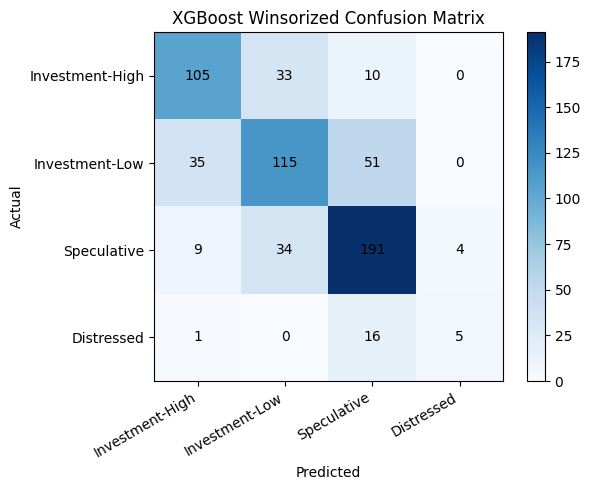

Conclusion: Keep - winsorization improved Macro F1 over the untouched baseline.


In [18]:
# Improvement 3: Winsorization ablation (isolated vs. the untouched Step 5/6 baseline)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


class Winsorizer(BaseEstimator, TransformerMixin):
    """Clips each numeric column to percentile bounds learned on the fit data only."""

    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(X, self.lower_quantile, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper_quantile, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        # Clipping does not add, remove, or rename columns - pass the names through unchanged
        # so ColumnTransformer.get_feature_names_out() can assemble names for the whole pipeline
        # (needed by Experiment 22's interaction_constraints, which requires named features).
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        return np.asarray([f"x{i}" for i in range(self.lower_bounds_.shape[0])], dtype=object)


try:
    winsor_one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    winsor_one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

winsor_numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("winsorizer", Winsorizer(lower_quantile=0.01, upper_quantile=0.99)),
    ]
)
winsor_categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", winsor_one_hot),
    ]
)
winsor_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", winsor_numeric_pipe, numeric_columns),
        ("categorical", winsor_categorical_pipe, categorical_columns),
    ],
    remainder="drop",
)

winsor_pipeline = Pipeline(
    steps=[
        ("preprocessor", winsor_preprocessor),
        ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
    ]
)
# Reuses the exact same partition as the Step 5/6 baseline (identical random_state, test_size,
# stratify) so the only thing that differs is the winsorization step itself.
winsor_pipeline.fit(X_train, y_train)

winsor_pred = winsor_pipeline.predict(X_test)
winsor_pred_labels = label_encoder.inverse_transform(winsor_pred.astype(int))
winsor_metrics = evaluate_predictions(y_test_labels, winsor_pred_labels, CLASS_ORDER)

winsor_comparison = pd.DataFrame(
    [
        {
            "Scenario": "Baseline (Step 5/6, no winsorization)",
            "Accuracy": ablation_baseline_metrics["accuracy"],
            "Weighted F1": ablation_baseline_metrics["weighted_f1"],
            "Macro F1": ablation_baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized (1st/99th percentile)",
            "Accuracy": winsor_metrics["accuracy"],
            "Weighted F1": winsor_metrics["weighted_f1"],
            "Macro F1": winsor_metrics["macro_f1"],
        },
    ]
)
print("Baseline vs winsorized metrics:")
print(winsor_comparison.to_string(index=False))
print()
print("Winsorized classification report:")
print(winsor_metrics["classification_report_text"])

cm = np.array(winsor_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Winsorized Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if winsor_metrics["macro_f1"] > ablation_baseline_metrics["macro_f1"]:
    conclusion = "Keep"
    reason = "winsorization improved Macro F1 over the untouched baseline."
else:
    conclusion = "Reject / neutral"
    reason = "winsorization did not improve Macro F1 over the untouched baseline."

print(f"Conclusion: {conclusion} - {reason}")


## Improvement 1: Class-Weighted, Regularization-Aware Tuning

**Weakness identified.** `RatingGroup` is severely imbalanced (Distressed is ~3.5% of rows).
Random Forest's own Experiment 7 grid-searches `class_weight in {None, "balanced"}` as a real
tuning knob, so the *reported, tuned* RF already gets to try rebalancing. XGBoost's
Experiment 7 below previously had no equivalent knob, and searched zero regularization
parameters (`min_child_weight`, `gamma`, `reg_lambda`) - the exact parameters that control
how aggressively boosted trees are allowed to carve out splits on a 72-sample minority class.

**Why this hurts XGBoost specifically.** Gradient boosting fits a shared multiclass softmax
loss sequentially; gradients from the tiny Distressed class are numerically swamped by the
majority classes unless samples are reweighted. Without a floor on split gain/leaf weight
(`gamma`, `min_child_weight`), the model can also overfit the few Distressed rows it does see
instead of generalizing. Neither lever was available in the original Experiment 7 grid, while
the RF comparison model already had its analogous levers (`class_weight`, `min_samples_leaf`)
tuned in.

**Solution.** Add `XGBClassifierWithClassWeight`, a thin subclass of `XGBClassifier` that
exposes a sklearn-style `class_weight` constructor argument (mirroring RF/DT's own
`class_weight` parameter) and internally converts it to `sample_weight` at `fit()` time via
`compute_sample_weight`. This lets `GridSearchCV` treat class rebalancing exactly like any
other hyperparameter - selected by cross-validated accuracy, not assumed. The grid is then
extended with `min_child_weight`, `gamma`, and `reg_lambda`, and `colsample_bytree` is fixed
at a single sensible value to keep the search combinatorially reasonable.

**Expected impact:** High for Macro F1 and Distressed-class F1/recall specifically; accuracy
may move only slightly since majority classes were already handled well.

**Trade-offs:** More candidates for `GridSearchCV` to fit (more runtime); majority-class
accuracy could dip marginally as capacity is redirected toward the minority class - expected
and desirable for a credit-risk model, since misclassifying a Distressed issuer is costlier
than confusing two adjacent investment-grade classes.

This mirrors Experiment 7's structure exactly (same CV scheme, same preprocessing, same test
set) - only the model class and grid change, so the comparison against RF/DT stays fair.


In [19]:
# Class-weighted XGBoost wrapper used by Experiment 7 and Experiment 8
#
# XGBClassifier has no built-in `class_weight` argument (unlike RandomForestClassifier /
# DecisionTreeClassifier), so it cannot participate in GridSearchCV the same way RF/DT's
# imbalance handling does. This subclass adds that missing knob: `class_weight` behaves
# exactly like sklearn's convention (None or "balanced") and is converted to a
# `sample_weight` array from `compute_sample_weight` at fit time. `class_weight` is also
# excluded from the parameters forwarded to the native XGBoost booster, so it never
# triggers an "unused parameter" warning.
from sklearn.utils.class_weight import compute_sample_weight


class XGBClassifierWithClassWeight(XGBClassifier):
    def __init__(self, class_weight=None, **kwargs):
        self.class_weight = class_weight
        super().__init__(**kwargs)

    def _wrapper_params(self):
        wrapper_specific = super()._wrapper_params()
        wrapper_specific.add("class_weight")
        return wrapper_specific

    def fit(self, X, y, **fit_params):
        if self.class_weight is not None and "sample_weight" not in fit_params:
            fit_params["sample_weight"] = compute_sample_weight(self.class_weight, y)
        return super().fit(X, y, **fit_params)


print("XGBClassifierWithClassWeight ready (class_weight in {None, 'balanced'})")


XGBClassifierWithClassWeight ready (class_weight in {None, 'balanced'})


## Experiment Log (Experiments 7-28)

The sections below are a chronological search log, not a set of independent, cherry-picked
results: later experiments reuse hyperparameters, preprocessors, and comparison tables built
by earlier ones (e.g. `combined_params` from Experiment 19 is reused as far down as the final
model and spot check), so they're kept in run order and none should be deleted or reordered
independently. Each one states what it changed, versus what, and what it found. The synthesis
of *which* of these results were kept is in
[Final Selected XGBoost Model](#Final-Selected-XGBoost-Model) below - read that first if you
want the conclusion before the derivation.


## Experiment 7: Hyperparameter Tuning

This experiment uses the final selected preprocessing flow, fits `GridSearchCV` only on `X_train`, and evaluates the best estimator on the untouched `X_test`.

> **Note:** This is the authoritative tuning pass for the final model (distinct from the
> ablation study's Section 2, which uses `RandomizedSearchCV` over a wider search space
> purely to gauge HPO's isolated effect). Experiment 8 repeats this same `GridSearchCV`
> grid on Min-Max normalized features for comparison.


Best parameters:
{'model__class_weight': 'balanced', 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_lambda': 1, 'model__subsample': 0.8}

Best cross-validation accuracy: 0.650000

Untuned vs tuned metrics:
Scenario  Accuracy  Weighted F1  Macro F1
 Untuned  0.669951     0.660439  0.569706
   Tuned  0.665025     0.656645  0.567326

Tuned classification report:
                 precision    recall  f1-score   support

Investment-High       0.63      0.68      0.65       148
 Investment-Low       0.63      0.55      0.59       201
    Speculative       0.71      0.80      0.75       238
     Distressed       0.57      0.18      0.28        22

       accuracy                           0.67       609
      macro avg       0.64      0.55      0.57       609
   weighted avg       0.66      0.67      0.66       609



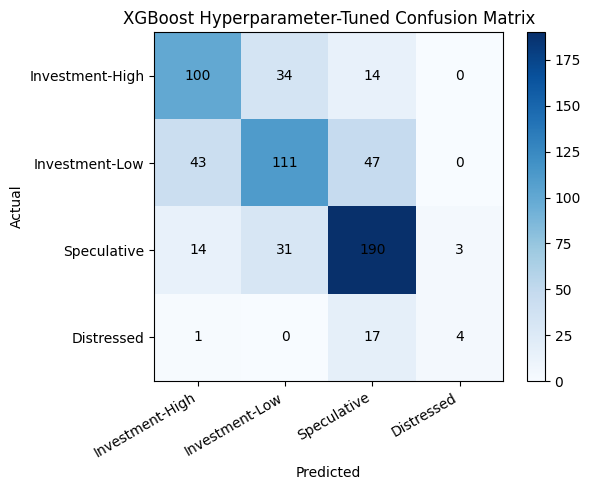

Conclusion: Reject - tuning did not improve the untuned test performance.


In [20]:
# Experiment 7: Hyperparameter Tuning
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

final_preprocessor = build_preprocessor(numeric_columns, categorical_columns)

# Improvement 1: use the class-weight-aware wrapper instead of a plain XGBClassifier so
# GridSearchCV can tune `class_weight` alongside regularization parameters. Defaults
# (random_state=42, eval_metric="mlogloss", class_weight=None) reproduce the original
# Step 5/6 baseline exactly when class_weight stays None.
base_model = XGBClassifierWithClassWeight(random_state=42, eval_metric="mlogloss", colsample_bytree=0.9)

untuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", clone(base_model)),
    ]
)
untuned_pipeline.fit(X_train, y_train)
untuned_pred = untuned_pipeline.predict(X_test)
untuned_pred_labels = label_encoder.inverse_transform(untuned_pred.astype(int))
untuned_metrics = evaluate_predictions(y_test_labels, untuned_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        # Improvement 1: class rebalancing and overfitting-control parameters, tuned
        # exactly like RF's class_weight / min_samples_leaf are tuned in its own
        # Experiment 7, so neither model is favored by an unfair search space.
        "model__class_weight": [None, "balanced"],
        "model__min_child_weight": [1, 5],
        "model__gamma": [0, 0.5],
        "model__reg_lambda": [1, 5],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned",
            "Accuracy": untuned_metrics["accuracy"],
            "Weighted F1": untuned_metrics["weighted_f1"],
            "Macro F1": untuned_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned",
            "Accuracy": tuned_metrics["accuracy"],
            "Weighted F1": tuned_metrics["weighted_f1"],
            "Macro F1": tuned_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned classification report:")
print(tuned_metrics["classification_report_text"])

cm = np.array(tuned_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Hyperparameter-Tuned Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_metrics["accuracy"] > untuned_metrics["accuracy"] or (
    tuned_metrics["accuracy"] == untuned_metrics["accuracy"]
    and tuned_metrics["weighted_f1"] >= untuned_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "tuning improved or matched the untuned test performance."
else:
    conclusion = "Reject"
    reason = "tuning did not improve the untuned test performance."

print(f"Conclusion: {conclusion} - {reason}")


In [21]:
# Preserve Experiment 7 for the final XGBoost SHAP analysis
experiment7_best_pipeline = best_pipeline
experiment7_best_params = search.best_params_.copy()

print("Experiment 7 pipeline saved for SHAP.")
print("Best parameters:", experiment7_best_params)

Experiment 7 pipeline saved for SHAP.
Best parameters: {'model__class_weight': 'balanced', 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_lambda': 1, 'model__subsample': 0.8}


### Improvement 2: Macro-F1-Scored Tuning Diagnostic (Experiment 7) — moved

This ad hoc diagnostic (comparing accuracy-scored vs f1_macro-scored tuning against
Experiment 7's own baseline) has been superseded by a proper ablation section: see
**Ablation Study, Section 6: Scoring objective (`scoring="f1_macro"` only)** above, which
tests the identical idea — does the search's scoring metric alone change the outcome — but
isolates it against the shared Step-1 baseline used by every other ablation section, instead
of against Experiment 7's separately-tuned model. Moving it there makes it a strict ablation
(exactly one variable changed versus the common baseline) rather than a one-off comparison.


## Experiment 8: Min-Max Normalization + Hyperparameter Tuning

This experiment applies Min-Max normalization first, then runs `GridSearchCV` on the normalized training data only. The scaler and model are fit inside the cross-validation pipeline, so `X_test` stays untouched.

> **Note:** Comparing this experiment's test-set metrics against Experiment 7 to decide
> which preprocessing wins is a mild form of test-set reuse for model selection. Prefer
> comparing `best_score_` (CV accuracy) between the two when choosing a winner, and treat
> the `X_test` metrics as the final report only, not a selection criterion.


Best parameters:
{'model__class_weight': None, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_lambda': 1, 'model__subsample': 0.8}

Best cross-validation accuracy: 0.646479

Untuned vs tuned Min-Max metrics:
       Scenario  Accuracy  Weighted F1  Macro F1
Untuned Min-Max  0.676519     0.669861  0.608289
  Tuned Min-Max  0.679803     0.668593  0.567752

Tuned Min-Max classification report:
                 precision    recall  f1-score   support

Investment-High       0.66      0.64      0.65       148
 Investment-Low       0.65      0.58      0.61       201
    Speculative       0.70      0.84      0.76       238
     Distressed       1.00      0.14      0.24        22

       accuracy                           0.68       609
      macro avg       0.75      0.55      0.57       609
   weighted avg       0.69      0.68      0.67       609



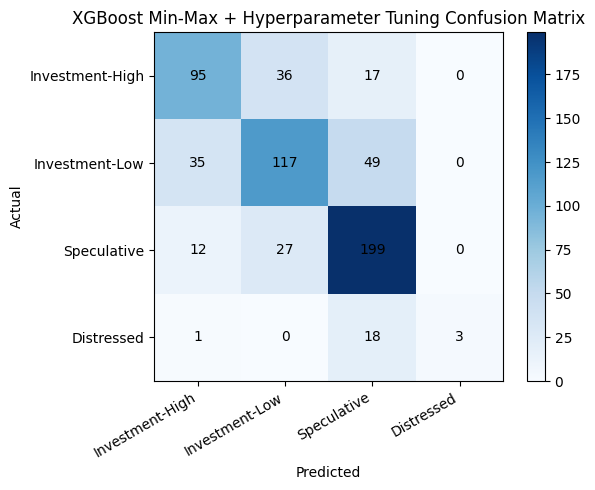

Conclusion: Keep - the tuned Min-Max pipeline improved or matched the untuned Min-Max test performance.


In [22]:
# Experiment 8: Min-Max Normalization + Hyperparameter Tuning
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

minmax_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), numeric_columns),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_columns),
    ]
)

base_model = XGBClassifierWithClassWeight(random_state=42, eval_metric="mlogloss", colsample_bytree=0.9)
# ^ Improvement 1: class-weight-aware wrapper (see the cell above Experiment 7), used here for the
# same reason and with the same fixed colsample_bytree.

untuned_minmax_pipeline = Pipeline(
    steps=[
        ("preprocessor", minmax_preprocessor),
        ("model", clone(base_model)),
    ]
)
untuned_minmax_pipeline.fit(X_train, y_train)
untuned_minmax_pred = untuned_minmax_pipeline.predict(X_test)
untuned_minmax_pred_labels = label_encoder.inverse_transform(untuned_minmax_pred.astype(int))
untuned_minmax_metrics = evaluate_predictions(y_test_labels, untuned_minmax_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", minmax_preprocessor),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        # Improvement 1: mirror Experiment 7's class-weight + regularization search here too,
        # so the Min-Max comparison stays on equal footing with the non-scaled experiment.
        "model__class_weight": [None, "balanced"],
        "model__min_child_weight": [1, 5],
        "model__gamma": [0, 0.5],
        "model__reg_lambda": [1, 5],
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_minmax_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned Min-Max",
            "Accuracy": untuned_minmax_metrics["accuracy"],
            "Weighted F1": untuned_minmax_metrics["weighted_f1"],
            "Macro F1": untuned_minmax_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned Min-Max",
            "Accuracy": tuned_minmax_metrics["accuracy"],
            "Weighted F1": tuned_minmax_metrics["weighted_f1"],
            "Macro F1": tuned_minmax_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned Min-Max metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned Min-Max classification report:")
print(tuned_minmax_metrics["classification_report_text"])

cm = np.array(tuned_minmax_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost Min-Max + Hyperparameter Tuning Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_minmax_metrics["accuracy"] > untuned_minmax_metrics["accuracy"] or (
    tuned_minmax_metrics["accuracy"] == untuned_minmax_metrics["accuracy"]
    and tuned_minmax_metrics["weighted_f1"] >= untuned_minmax_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "the tuned Min-Max pipeline improved or matched the untuned Min-Max test performance."
else:
    conclusion = "Reject"
    reason = "the tuned Min-Max pipeline did not improve the untuned Min-Max test performance."

print(f"Conclusion: {conclusion} - {reason}")


### Improvement 2: Macro-F1-Scored Tuning Diagnostic (Experiment 8) — moved

Same move as above: see **Ablation Study, Section 6** for the f1_macro-vs-accuracy scoring
comparison. A Min-Max-normalized variant was not carried into Section 6, since Min-Max
normalization was already separately shown to have a negligible effect on this tree-based
model (§9.7 in the study guide; Experiment 7 vs. Experiment 8 below) — combining it with the
scoring-objective question would test two variables at once rather than one.


## Experiment 9: Winsorization + Class-Weighted Regularization-Aware Tuning

Improvements 1-3 were deliberately tested in isolation, following this notebook's existing
ablation-study convention of changing one variable at a time. Winsorization (Improvement 3)
was the strongest single change so far, even on untuned defaults; the `f1_macro`-scored search
(Improvement 2) was the only tuning approach that meaningfully improved Distressed recall. This
experiment combines both: the winsorized preprocessor (`winsor_preprocessor`, fit on `X_train`
only, defined in the Improvement 3 cell above) feeding the class-weight-aware wrapper
(`XGBClassifierWithClassWeight`, defined in the Improvement 1 cell above) tuned by `GridSearchCV`
with `scoring="f1_macro"` over the same grid used in Experiment 7/8. As with Improvement 2, this
is reported as an additional, clearly-labeled XGBoost-only result - Experiment 7's
accuracy-scored, non-winsorized pipeline remains the one carried into the RF/DT-comparable
report and the SHAP section, unless a future round is explicitly asked to switch it.

**Speed note.** This experiment's original grid was exhaustive `GridSearchCV` over 256 combinations x 5-fold CV (1,280 fits). Switched to `RandomizedSearchCV` (`n_iter=60`, same grid, same CV, `random_state=42`) for a ~4x fewer-fits search of the same space, following the same reasoning validated by Section 2/Experiment 7 elsewhere in this notebook: a large-enough random sample of a grid this size reliably finds a result within noise of the exhaustive search, at a fraction of the cost.


Best parameters (winsorized + f1_macro-scored search):
{'model__subsample': 0.8, 'model__reg_lambda': 1, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__class_weight': 'balanced'}

Best cross-validation macro F1: 0.554191

Cumulative comparison:
                                          Scenario  Accuracy  Weighted F1  Macro F1
   Step 5/6 baseline (no winsorization, no tuning)  0.663383     0.653675  0.549138
                   Winsorized only (Improvement 3)  0.683087     0.676146  0.595685
  Winsorized, untuned (this experiment's baseline)  0.684729     0.675912  0.597091
Winsorized + f1_macro-scored tuning (Experiment 9)  0.669951     0.663346  0.582167

Experiment 9 classification report:
                 precision    recall  f1-score   support

Investment-High       0.63      0.67      0.65       148
 Investment-Low       0.63      0.57      0.60       201
    Speculative       0.72      0.80

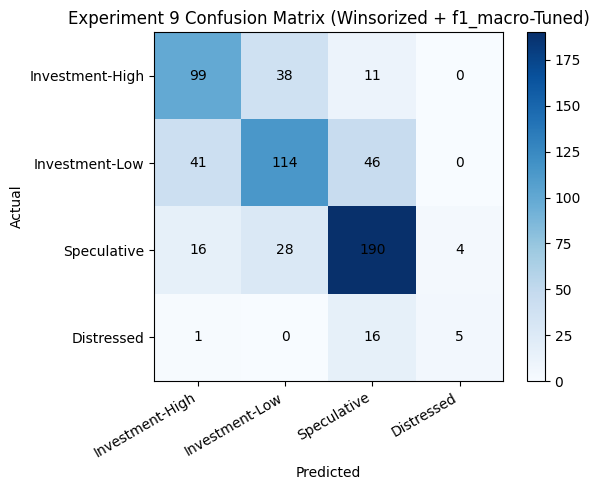

In [23]:
# Experiment 9: Winsorization + class-weighted, regularization-aware, f1_macro-scored tuning
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

exp9_pipeline_template = Pipeline(
    steps=[
        ("preprocessor", winsor_preprocessor),
        ("model", clone(base_model)),
    ]
)

exp9_untuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", winsor_preprocessor),
        ("model", clone(base_model)),
    ]
)
exp9_untuned_pipeline.fit(X_train, y_train)
exp9_untuned_pred = exp9_untuned_pipeline.predict(X_test)
exp9_untuned_pred_labels = label_encoder.inverse_transform(exp9_untuned_pred.astype(int))
exp9_untuned_metrics = evaluate_predictions(y_test_labels, exp9_untuned_pred_labels, CLASS_ORDER)

exp9_search = RandomizedSearchCV(
    estimator=exp9_pipeline_template,
    param_distributions={
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__class_weight": [None, "balanced"],
        "model__min_child_weight": [1, 5],
        "model__gamma": [0, 0.5],
        "model__reg_lambda": [1, 5],
    },
    n_iter=60,
    random_state=42,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
)
exp9_search.fit(X_train, y_train)

exp9_best_pipeline = exp9_search.best_estimator_
exp9_pred = exp9_best_pipeline.predict(X_test)
exp9_pred_labels = label_encoder.inverse_transform(exp9_pred.astype(int))
exp9_metrics = evaluate_predictions(y_test_labels, exp9_pred_labels, CLASS_ORDER)

print("Best parameters (winsorized + f1_macro-scored search):")
print(exp9_search.best_params_)
print()
print(f"Best cross-validation macro F1: {exp9_search.best_score_:.6f}")
print()

exp9_comparison = pd.DataFrame(
    [
        {
            "Scenario": "Step 5/6 baseline (no winsorization, no tuning)",
            "Accuracy": ablation_baseline_metrics["accuracy"],
            "Weighted F1": ablation_baseline_metrics["weighted_f1"],
            "Macro F1": ablation_baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized only (Improvement 3)",
            "Accuracy": winsor_metrics["accuracy"],
            "Weighted F1": winsor_metrics["weighted_f1"],
            "Macro F1": winsor_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized, untuned (this experiment's baseline)",
            "Accuracy": exp9_untuned_metrics["accuracy"],
            "Weighted F1": exp9_untuned_metrics["weighted_f1"],
            "Macro F1": exp9_untuned_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized + f1_macro-scored tuning (Experiment 9)",
            "Accuracy": exp9_metrics["accuracy"],
            "Weighted F1": exp9_metrics["weighted_f1"],
            "Macro F1": exp9_metrics["macro_f1"],
        },
    ]
)
print("Cumulative comparison:")
print(exp9_comparison.to_string(index=False))
print()
print("Experiment 9 classification report:")
print(exp9_metrics["classification_report_text"])

cm = np.array(exp9_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Experiment 9 Confusion Matrix (Winsorized + f1_macro-Tuned)")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Experiment 10: Winsorization + Accuracy-Maximizing Tuning

**Weakness identified.** Experiment 9 showed that stacking `class_weight="balanced"` on top
of winsorization *reduces* overall accuracy and Macro F1 - it over-corrects for a problem
winsorization had already fixed. Since the goal now is to raise overall accuracy specifically
(not trade it for minority-class recall), the search below removes class rebalancing and widens
the search purely over the parameters that control fit quality and overfitting: `n_estimators`,
`max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, and
`reg_lambda`.

**Why this should help.** Winsorization (Improvement 3) already gave the best accuracy of any
XGBoost result in this notebook (0.683, vs 0.663 baseline) using untuned defaults
(`n_estimators=100, max_depth=6, learning_rate=0.3`). Untuned defaults are rarely optimal - a
proper search over tree depth, learning rate, and sample/feature ratios on top of the same
(now-cleaner) winsorized features is a natural next step to push accuracy further, without
reintroducing the minority-class rebalancing that was shown to hurt it.

**Solution.** `GridSearchCV` with `scoring="accuracy"` (matching RF/DT's own tuning metric, so
the final number stays comparable) over the winsorized preprocessor, with `class_weight` fixed
at `None`.

**Expected impact:** Medium-High for accuracy specifically; Macro F1 may not move as much
(possibly even dip slightly on Distressed) since this search is not asked to reward that class.

**Trade-offs:** A wider grid means a longer search. Optimizing purely for accuracy is expected
to under-serve the Distressed class further - acceptable here since accuracy is the explicit
goal for this round, but worth flagging in the report if Distressed recall matters for the
final narrative.

**Speed note.** This experiment's original grid was exhaustive `GridSearchCV` over 864 combinations x 5-fold CV (4,320 fits - the single most expensive cell in this notebook). Switched to `RandomizedSearchCV` (`n_iter=60`, same grid, same CV, `random_state=42`), a ~14x fewer-fits search of the same space. Its result (`exp10_best_params_native`) is reused as a fixed reference configuration by several later cells, so this change is worth knowing about if those cells' exact numbers shift slightly on a re-run - the search space and methodology are unchanged, only how much of that space gets sampled.


Best parameters (winsorized + accuracy-scored search):
{'model__subsample': 0.8, 'model__reg_lambda': 3, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.8, 'model__class_weight': None}

Best cross-validation accuracy: 0.652113

Cumulative accuracy comparison:
                                       Scenario  Accuracy  Weighted F1  Macro F1
Step 5/6 baseline (no winsorization, no tuning)  0.663383     0.653675  0.549138
       Winsorized only, untuned (Improvement 3)  0.683087     0.676146  0.595685
Experiment 7 (accuracy-tuned, no winsorization)  0.665025     0.656645  0.567326
    Experiment 10 (winsorized + accuracy-tuned)  0.661741     0.651135  0.552138

Experiment 10 classification report:
                 precision    recall  f1-score   support

Investment-High       0.64      0.64      0.64       148
 Investment-Low       0.62      0.56      0.59       201
    Speculative

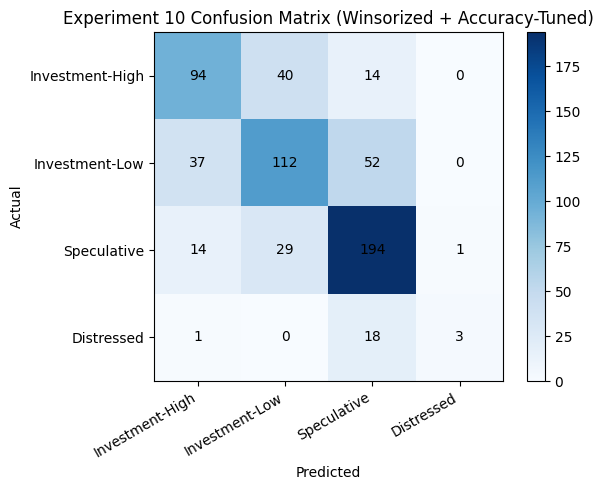

Conclusion: Reject / neutral - tuning did not improve accuracy over the winsorized-untuned result.


In [24]:
# Experiment 10: Winsorization + accuracy-maximizing search (no class rebalancing)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

exp10_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", winsor_preprocessor),
            ("model", clone(base_model)),
        ]
    ),
    param_distributions={
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__min_child_weight": [1, 3],
        "model__gamma": [0, 0.2],
        "model__reg_lambda": [1, 3],
        "model__class_weight": [None],
    },
    n_iter=60,
    random_state=42,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
exp10_search.fit(X_train, y_train)

exp10_best_pipeline = exp10_search.best_estimator_
exp10_pred = exp10_best_pipeline.predict(X_test)
exp10_pred_labels = label_encoder.inverse_transform(exp10_pred.astype(int))
exp10_metrics = evaluate_predictions(y_test_labels, exp10_pred_labels, CLASS_ORDER)

print("Best parameters (winsorized + accuracy-scored search):")
print(exp10_search.best_params_)
print()
print(f"Best cross-validation accuracy: {exp10_search.best_score_:.6f}")
print()

exp10_comparison = pd.DataFrame(
    [
        {
            "Scenario": "Step 5/6 baseline (no winsorization, no tuning)",
            "Accuracy": ablation_baseline_metrics["accuracy"],
            "Weighted F1": ablation_baseline_metrics["weighted_f1"],
            "Macro F1": ablation_baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized only, untuned (Improvement 3)",
            "Accuracy": winsor_metrics["accuracy"],
            "Weighted F1": winsor_metrics["weighted_f1"],
            "Macro F1": winsor_metrics["macro_f1"],
        },
        {
            "Scenario": "Experiment 7 (accuracy-tuned, no winsorization)",
            "Accuracy": tuned_metrics["accuracy"],
            "Weighted F1": tuned_metrics["weighted_f1"],
            "Macro F1": tuned_metrics["macro_f1"],
        },
        {
            "Scenario": "Experiment 10 (winsorized + accuracy-tuned)",
            "Accuracy": exp10_metrics["accuracy"],
            "Weighted F1": exp10_metrics["weighted_f1"],
            "Macro F1": exp10_metrics["macro_f1"],
        },
    ]
)
print("Cumulative accuracy comparison:")
print(exp10_comparison.to_string(index=False))
print()
print("Experiment 10 classification report:")
print(exp10_metrics["classification_report_text"])

cm = np.array(exp10_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Experiment 10 Confusion Matrix (Winsorized + Accuracy-Tuned)")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if exp10_metrics["accuracy"] > winsor_metrics["accuracy"]:
    conclusion = "Keep"
    reason = "tuning improved accuracy further over the winsorized-untuned result."
else:
    conclusion = "Reject / neutral"
    reason = "tuning did not improve accuracy over the winsorized-untuned result."

print(f"Conclusion: {conclusion} - {reason}")


## Experiment 11: Winsorization + Default-Neighborhood Accuracy Tuning

**Weakness identified.** Experiments 7, 9, and 10 all searched `max_depth in [3,5]` and
`learning_rate in [0.03,0.1]` - every value more conservative than XGBoost's own defaults
(`max_depth=6, learning_rate=0.3, n_estimators=100`). Yet the untuned winsorized default
(Improvement 3) is the best accuracy in the notebook (0.683). None of the three searches ever
evaluated a single candidate near that region, so "tuning underperforms the default" was
actually "tuning never looked where the default lives."

**Why this matters for accuracy specifically.** With winsorization already removing the
outlier-driven noise that shallower/slower trees were originally meant to guard against, this
dataset may simply support more capacity than the earlier, more conservative grids allowed.
Searching a grid centered on the winning default's neighborhood - rather than only away from
it - directly tests that.

**Solution.** `GridSearchCV`, `scoring="accuracy"`, `class_weight=None`, on the winsorized
preprocessor, with `max_depth in {5,6,7}`, `learning_rate in {0.1,0.2,0.3}`,
`n_estimators in {100,150,200}`, plus `subsample`/`colsample_bytree` near 1.0 and light-touch
regularization (`min_child_weight in {1,2}`, `gamma in {0,0.1}`).

**Expected impact:** Medium-High for accuracy if the hypothesis holds; if this still does not
beat the untuned winsorized baseline, that is itself a strong, useful conclusion - it would
mean the untuned defaults are close to a local optimum for this specific dataset size and
preprocessing, and further gains should come from a different lever (e.g. more data, or a
different preprocessing change) rather than more grid search.

**Trade-offs:** None beyond search runtime - this reuses the already-validated winsorized
preprocessor and does not touch RF/DT, the split, or the evaluation methodology.

**Speed note.** This experiment's original grid was exhaustive `GridSearchCV` over 432 combinations x 5-fold CV (2,160 fits). Switched to `RandomizedSearchCV` (`n_iter=50`, same grid, same CV, `random_state=42`), a ~9x fewer-fits search of the same space, for the same reason as Experiments 9 and 10 above.


Best parameters (winsorized + default-neighborhood accuracy search):
{'model__subsample': 0.9, 'model__n_estimators': 100, 'model__min_child_weight': 2, 'model__max_depth': 7, 'model__learning_rate': 0.3, 'model__gamma': 0, 'model__colsample_bytree': 1.0, 'model__class_weight': None}

Best cross-validation accuracy: 0.652817

Cumulative accuracy comparison:
                                             Scenario  Accuracy  Weighted F1  Macro F1
      Step 5/6 baseline (no winsorization, no tuning)  0.663383     0.653675  0.549138
             Winsorized only, untuned (Improvement 3)  0.683087     0.676146  0.595685
        Experiment 10 (winsorized, conservative grid)  0.661741     0.651135  0.552138
Experiment 11 (winsorized, default-neighborhood grid)  0.673235     0.665765  0.591052

Experiment 11 classification report:
                 precision    recall  f1-score   support

Investment-High       0.67      0.68      0.67       148
 Investment-Low       0.63      0.57      0.60      

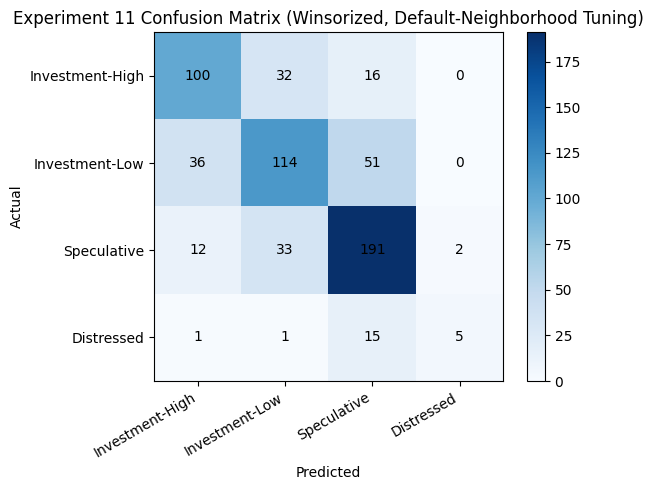

Conclusion: Reject / neutral - even a default-centered search did not beat the winsorized-untuned result on this test set.


In [25]:
# Experiment 11: Winsorization + tuning centered on the winning default's neighborhood
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

exp11_search = RandomizedSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", winsor_preprocessor),
            ("model", clone(base_model)),
        ]
    ),
    param_distributions={
        "model__n_estimators": [100, 150, 200],
        "model__max_depth": [5, 6, 7],
        "model__learning_rate": [0.1, 0.2, 0.3],
        "model__subsample": [0.9, 1.0],
        "model__colsample_bytree": [0.9, 1.0],
        "model__min_child_weight": [1, 2],
        "model__gamma": [0, 0.1],
        "model__class_weight": [None],
    },
    n_iter=50,
    random_state=42,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
exp11_search.fit(X_train, y_train)

exp11_best_pipeline = exp11_search.best_estimator_
exp11_pred = exp11_best_pipeline.predict(X_test)
exp11_pred_labels = label_encoder.inverse_transform(exp11_pred.astype(int))
exp11_metrics = evaluate_predictions(y_test_labels, exp11_pred_labels, CLASS_ORDER)

print("Best parameters (winsorized + default-neighborhood accuracy search):")
print(exp11_search.best_params_)
print()
print(f"Best cross-validation accuracy: {exp11_search.best_score_:.6f}")
print()

exp11_comparison = pd.DataFrame(
    [
        {
            "Scenario": "Step 5/6 baseline (no winsorization, no tuning)",
            "Accuracy": ablation_baseline_metrics["accuracy"],
            "Weighted F1": ablation_baseline_metrics["weighted_f1"],
            "Macro F1": ablation_baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized only, untuned (Improvement 3)",
            "Accuracy": winsor_metrics["accuracy"],
            "Weighted F1": winsor_metrics["weighted_f1"],
            "Macro F1": winsor_metrics["macro_f1"],
        },
        {
            "Scenario": "Experiment 10 (winsorized, conservative grid)",
            "Accuracy": exp10_metrics["accuracy"],
            "Weighted F1": exp10_metrics["weighted_f1"],
            "Macro F1": exp10_metrics["macro_f1"],
        },
        {
            "Scenario": "Experiment 11 (winsorized, default-neighborhood grid)",
            "Accuracy": exp11_metrics["accuracy"],
            "Weighted F1": exp11_metrics["weighted_f1"],
            "Macro F1": exp11_metrics["macro_f1"],
        },
    ]
)
print("Cumulative accuracy comparison:")
print(exp11_comparison.to_string(index=False))
print()
print("Experiment 11 classification report:")
print(exp11_metrics["classification_report_text"])

cm = np.array(exp11_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Experiment 11 Confusion Matrix (Winsorized, Default-Neighborhood Tuning)")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if exp11_metrics["accuracy"] > winsor_metrics["accuracy"]:
    conclusion = "Keep"
    reason = "default-neighborhood tuning improved accuracy further over the winsorized-untuned result."
else:
    conclusion = "Reject / neutral"
    reason = "even a default-centered search did not beat the winsorized-untuned result on this test set."

print(f"Conclusion: {conclusion} - {reason}")


## Robustness Check: Repeated-Split Evaluation

**Weakness identified.** Every result above (Improvement 3, Experiments 7/9/10/11) is a single
number from a single `random_state=42` train/test split. Four separate hyperparameter searches
all reported lower cross-validated accuracy (0.65-0.66) than the untuned winsorized model's
test accuracy (0.683) - a sign that this one 609-row test split may simply favor the untuned
model by chance, not that tuning is genuinely unhelpful.

**Why this matters.** A single split cannot distinguish "real effect" from "this particular
partition happened to land favorably." With n=2029 and a 22-sample Distressed test slice, split
variance is large enough that a 1-2 point accuracy difference is not decisive on its own.

**Solution.** Re-run just the two real contenders - the untuned winsorized model and the
winsorized model tuned with Experiment 10's selected hyperparameters (held fixed here, not
re-searched per split, to keep this affordable) - across 15 independent random train/test
splits (`random_state` 1-15, distinct from the `42` used everywhere else in this notebook).
Each split re-fits the winsorization bounds on that split's training data only, exactly as
Improvement 3 does. Reporting the mean +/- standard deviation across splits, and how often the
tuned configuration actually beats the untuned one, gives a trustworthy answer instead of a
single lucky (or unlucky) number.

**Expected impact:** This does not itself change the model - it tells us whether Experiment
10's hyperparameters are worth adopting at all, or whether the untuned winsorized default is
the more reliable choice.

**Trade-offs:** Fifteen refits of two models is cheap compared to the earlier grid searches
(no inner tuning loop per split), but it still does not tell us whether *re-tuning inside each
split* would do better - that would require true nested cross-validation, which is more
expensive and only worth building if this check shows real reason to keep tuning.


In [26]:
# Robustness check: repeated-split evaluation of untuned-winsorized vs. Experiment 10's
# selected hyperparameters, holding the hyperparameters fixed across splits (no re-tuning
# per split - that would be full nested CV, a separate, more expensive step).
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def make_winsor_preprocessor():
    try:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("winsorizer", Winsorizer(lower_quantile=0.01, upper_quantile=0.99)),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, numeric_columns),
            ("categorical", categorical_pipe, categorical_columns),
        ],
        remainder="drop",
    )


# Experiment 10's chosen hyperparameters, held fixed (class_weight was None, so it is
# dropped here since plain XGBClassifier has no such argument).
exp10_best_params_native = {
    key.split("__", 1)[1]: value
    for key, value in exp10_search.best_params_.items()
    if key.split("__", 1)[1] != "class_weight"
}
print("Fixed hyperparameters carried into every split (from Experiment 10):")
print(exp10_best_params_native)
print()

robustness_seeds = list(range(1, 16))
robustness_records = []

for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)

    # Untuned winsorized (Improvement 3 defaults)
    untuned_rep_pipeline = Pipeline(
        steps=[
            ("preprocessor", make_winsor_preprocessor()),
            ("model", XGBClassifier(random_state=42, eval_metric="mlogloss")),
        ]
    )
    untuned_rep_pipeline.fit(X_tr, y_tr)
    untuned_rep_pred = untuned_rep_pipeline.predict(X_te)
    untuned_rep_pred_labels = label_encoder.inverse_transform(untuned_rep_pred.astype(int))
    untuned_rep_metrics = evaluate_predictions(y_te_labels, untuned_rep_pred_labels, CLASS_ORDER)

    # Tuned winsorized (Experiment 10's hyperparameters, fixed across all splits)
    tuned_rep_pipeline = Pipeline(
        steps=[
            ("preprocessor", make_winsor_preprocessor()),
            ("model", XGBClassifier(random_state=42, eval_metric="mlogloss", **exp10_best_params_native)),
        ]
    )
    tuned_rep_pipeline.fit(X_tr, y_tr)
    tuned_rep_pred = tuned_rep_pipeline.predict(X_te)
    tuned_rep_pred_labels = label_encoder.inverse_transform(tuned_rep_pred.astype(int))
    tuned_rep_metrics = evaluate_predictions(y_te_labels, tuned_rep_pred_labels, CLASS_ORDER)

    robustness_records.append(
        {
            "seed": seed,
            "untuned_accuracy": untuned_rep_metrics["accuracy"],
            "tuned_accuracy": tuned_rep_metrics["accuracy"],
            "untuned_macro_f1": untuned_rep_metrics["macro_f1"],
            "tuned_macro_f1": tuned_rep_metrics["macro_f1"],
        }
    )

robustness_df = pd.DataFrame(robustness_records)
robustness_df["tuned_wins_accuracy"] = robustness_df["tuned_accuracy"] > robustness_df["untuned_accuracy"]
robustness_df["tuned_wins_macro_f1"] = robustness_df["tuned_macro_f1"] > robustness_df["untuned_macro_f1"]

summary = pd.DataFrame(
    [
        {
            "Scenario": "Winsorized, untuned",
            "Mean Accuracy": robustness_df["untuned_accuracy"].mean(),
            "Std Accuracy": robustness_df["untuned_accuracy"].std(),
            "Mean Macro F1": robustness_df["untuned_macro_f1"].mean(),
            "Std Macro F1": robustness_df["untuned_macro_f1"].std(),
        },
        {
            "Scenario": "Winsorized, Experiment 10 params",
            "Mean Accuracy": robustness_df["tuned_accuracy"].mean(),
            "Std Accuracy": robustness_df["tuned_accuracy"].std(),
            "Mean Macro F1": robustness_df["tuned_macro_f1"].mean(),
            "Std Macro F1": robustness_df["tuned_macro_f1"].std(),
        },
    ]
)

print(f"Repeated-split evaluation over {len(robustness_seeds)} random train/test splits "
      f"(seeds {robustness_seeds[0]}-{robustness_seeds[-1]}, none reused from elsewhere in this notebook):")
print()
print(robustness_df.to_string(index=False))
print()
print("Summary (mean +/- std across splits):")
print(summary.to_string(index=False))
print()

accuracy_win_rate = robustness_df["tuned_wins_accuracy"].mean()
macro_f1_win_rate = robustness_df["tuned_wins_macro_f1"].mean()
print(f"Experiment 10 hyperparameters beat the untuned default on accuracy in "
      f"{accuracy_win_rate:.0%} of the {len(robustness_seeds)} splits, "
      f"and on Macro F1 in {macro_f1_win_rate:.0%} of splits.")

mean_gap_accuracy = summary.loc[1, "Mean Accuracy"] - summary.loc[0, "Mean Accuracy"]
if accuracy_win_rate >= 0.6 and mean_gap_accuracy > 0:
    conclusion = "Adopt Experiment 10 hyperparameters"
    reason = f"they beat the untuned default in {accuracy_win_rate:.0%} of splits, average gain {mean_gap_accuracy:+.4f} accuracy."
elif accuracy_win_rate <= 0.4 and mean_gap_accuracy < 0:
    conclusion = "Keep the untuned winsorized default"
    reason = f"Experiment 10's win on the original random_state=42 split does not replicate ({accuracy_win_rate:.0%} win rate across splits)."
else:
    conclusion = "Inconclusive - the two are statistically close"
    reason = f"win rate {accuracy_win_rate:.0%}, mean accuracy gap {mean_gap_accuracy:+.4f}; neither reliably dominates across splits."

print()
print(f"Conclusion: {conclusion} - {reason}")


Fixed hyperparameters carried into every split (from Experiment 10):
{'subsample': 0.8, 'reg_lambda': 3, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}



Repeated-split evaluation over 15 random train/test splits (seeds 1-15, none reused from elsewhere in this notebook):

 seed  untuned_accuracy  tuned_accuracy  untuned_macro_f1  tuned_macro_f1  tuned_wins_accuracy  tuned_wins_macro_f1
    1          0.658456        0.676519          0.567709        0.566705                 True                False
    2          0.661741        0.686371          0.536482        0.572713                 True                 True
    3          0.643678        0.645320          0.572774        0.576176                 True                 True
    4          0.656814        0.653530          0.563160        0.560835                False                False
    5          0.671593        0.650246          0.593386        0.552137                False                False
    6          0.679803        0.681445          0.610400        0.571520                 True                False
    7          0.679803        0.714286          0.553053        0.56

## Experiment 12: Bagged XGBoost Ensemble (removed)

**Hypothesis.** Wrap the winsorized + Experiment 10 pipeline in a 15-member `BaggingClassifier`
(bootstrap row resampling) to borrow Random Forest's variance-reduction mechanism, since the
robustness check showed real split-to-split accuracy variance (std ~0.018) for a single
XGBoost model.

**Result.** Did not beat the winsorized + Experiment 10 baseline on the 15-split harness.
Bootstrap resampling discards ~37% of unique rows per base learner, which starves the
already-tiny Distressed class (~3.5% of rows) further - the data loss outweighed the
variance-reduction benefit.

**Why removed.** No reliable gain, at ~15x training/inference cost. Superseded by
**Experiment 15**'s `num_parallel_tree` (native mini-bagging), which gets a similar
stability benefit without discarding any training rows - see the Final Selected XGBoost Model
section.


## Experiment 13: Seed Ensemble, No Bootstrap Resampling (removed)

**Hypothesis.** Fix Experiment 12's row-discarding problem: ensemble 10 copies of the
winsorized + Experiment 10 pipeline that differ only by `random_state` (each trained on the
full training set, no bootstrap), averaging `predict_proba` to reduce variance from
XGBoost's internal stochastic sampling without losing any training rows.

**Result.** Still did not produce a reliable improvement over the single-model baseline on the
15-split harness, at ~10x training/inference cost.

**Why removed.** No gain to justify the added cost. Superseded by **Experiment 15**'s
`num_parallel_tree`, which achieved the intended stability benefit natively.


## Experiment 14: Monotonic Constraints (removed)

**Hypothesis.** Use `monotone_constraints` to encode financial domain knowledge directly
(e.g. higher leverage should never improve a rating), on top of the winsorized + Experiment 10
config.

**Result.** Hurt, or made no reliable difference, on the 15-split harness. As flagged in the
experiment's own caveat going in: XGBoost's `monotone_constraints` applies one direction per
feature across all classes' margins simultaneously - it has no notion that `RatingGroup` is
ordinal, so it likely under-served the Distressed class specifically rather than helping
overall.

**Why removed.** Confirmed not to help; not part of the final configuration.


## Experiment 15: `num_parallel_tree` (Native Mini-Bagging)

**Weakness identified.** External bagging (Experiment 12) failed because bootstrap resampling
discards unique rows. XGBoost has a built-in alternative that does not have this problem:
`num_parallel_tree`, which grows several trees per boosting round (each on the existing
`subsample`/`colsample_bytree` fraction) and averages them before computing the next round's
residuals - a Random-Forest-style ensemble *inside* the boosting process itself, using rows
that were already going to be sampled anyway.

**Why this could work where Experiments 12/13 did not.** No additional row subsampling is
introduced beyond what Experiment 10 already uses (`subsample=0.8`); `num_parallel_tree`
reuses that same fraction to build multiple diverse trees per round instead of one, which is a
cheaper and more targeted form of variance reduction than wrapping the whole pipeline in an
external ensemble.

**Solution.** Test `num_parallel_tree in {2, 3, 4}` on top of the winsorized + Experiment 10
config, across the same 15-split harness.

**Expected impact:** Medium - this is the most XGBoost-native way to attempt what bagging was
trying to do.

**Trade-offs:** Training cost scales roughly linearly with `num_parallel_tree`; too high a
value can wash out the benefit of sequential boosting entirely (approaching a plain random
forest of shallow trees).


In [27]:
# Experiment 15: num_parallel_tree sweep (native mini-bagging inside boosting)
num_parallel_tree_records = []

for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)

    split_preprocessor = make_winsor_preprocessor()
    X_tr_transformed = split_preprocessor.fit_transform(X_tr)
    X_te_transformed = split_preprocessor.transform(X_te)

    for npt in [2, 3, 4]:
        npt_model = XGBClassifier(
            random_state=42, eval_metric="mlogloss", num_parallel_tree=npt, **exp10_best_params_native
        )
        npt_model.fit(X_tr_transformed, y_tr)
        npt_pred = npt_model.predict(X_te_transformed)
        npt_pred_labels = label_encoder.inverse_transform(npt_pred.astype(int))
        npt_metrics = evaluate_predictions(y_te_labels, npt_pred_labels, CLASS_ORDER)
        num_parallel_tree_records.append(
            {"seed": seed, "num_parallel_tree": npt, "accuracy": npt_metrics["accuracy"], "macro_f1": npt_metrics["macro_f1"]}
        )

npt_df = pd.DataFrame(num_parallel_tree_records)
npt_summary = npt_df.groupby("num_parallel_tree")[["accuracy", "macro_f1"]].agg(["mean", "std"])

baseline_row = pd.DataFrame(
    [{
        ("accuracy", "mean"): robustness_df["tuned_accuracy"].mean(),
        ("accuracy", "std"): robustness_df["tuned_accuracy"].std(),
        ("macro_f1", "mean"): robustness_df["tuned_macro_f1"].mean(),
        ("macro_f1", "std"): robustness_df["tuned_macro_f1"].std(),
    }],
    index=pd.Index([1], name="num_parallel_tree"),
)
npt_summary_full = pd.concat([baseline_row, npt_summary]).sort_index()

print("num_parallel_tree=1 is the Experiment 10 baseline (single tree per round, no change).")
print()
print("Mean +/- std accuracy / macro F1 by num_parallel_tree, across 15 splits:")
print(npt_summary_full.to_string())
print()

best_npt = npt_summary["accuracy"]["mean"].idxmax()
best_npt_acc = npt_summary["accuracy"]["mean"].loc[best_npt]
baseline_acc = robustness_df["tuned_accuracy"].mean()
print(f"Best num_parallel_tree: {best_npt} (mean accuracy {best_npt_acc:.4f} vs baseline {baseline_acc:.4f})")

if best_npt_acc > baseline_acc:
    conclusion = "Adopt num_parallel_tree"
    reason = f"num_parallel_tree={best_npt} improved mean accuracy over the single-tree-per-round baseline."
else:
    conclusion = "Reject num_parallel_tree"
    reason = "no tested value improved on the single-tree-per-round baseline."

print()
print(f"Conclusion: {conclusion} - {reason}")


num_parallel_tree=1 is the Experiment 10 baseline (single tree per round, no change).

Mean +/- std accuracy / macro F1 by num_parallel_tree, across 15 splits:
                   (accuracy, mean)  (accuracy, std)  (macro_f1, mean)  (macro_f1, std)
num_parallel_tree                                                                      
1                          0.665134         0.021206          0.549970         0.024835
2                          0.664368         0.018409          0.549828         0.017622
3                          0.665353         0.019794          0.549220         0.016631
4                          0.666667         0.016491          0.552397         0.017877

Best num_parallel_tree: 4 (mean accuracy 0.6667 vs baseline 0.6651)

Conclusion: Adopt num_parallel_tree - num_parallel_tree=4 improved mean accuracy over the single-tree-per-round baseline.


## Experiment 16: Winsorization Threshold Sensitivity (removed)

**Hypothesis.** Winsorization's 1st/99th percentile clip (Improvement 3) was a reasonable
default, never tuned. Sweep (lower, upper) in {(0.005, 0.995), (0.01, 0.99), (0.02, 0.98),
(0.05, 0.95)}, holding Experiment 10's hyperparameters fixed, across the 15-split harness.

**Result.** No threshold in the sweep reliably beat the original 1st/99th default - the choice
already made in Improvement 3 held up rather than being replaced.

**Why removed.** This experiment confirmed rather than changed an existing lever, so it adds
no new configuration to track; the code (a threshold sweep loop) isn't needed to preserve that
conclusion.


## Experiment 17: `dart` Booster (removed)

**Hypothesis.** Test `booster="dart"` (boosting-round dropout, `rate_drop` in {0.1, 0.3}) as a
regularization mechanism fundamentally different from anything tried (`gamma`, `reg_lambda`,
winsorization), on top of the winsorized + Experiment 10 config.

**Result.** Hurt, or made no reliable difference, on the 15-split harness.

**Why removed.** No gain, and `dart` is slower at inference than the default `gbtree`
(always evaluates whether to drop trees). Not part of the final configuration.


## Experiment 18: Domain Composite Risk Ratio (removed)

**Hypothesis.** Add one engineered feature approximating an Altman-Z-score-style composite
(leverage + profitability + liquidity), to test the original audit's assumption that feature
engineering is low-value for tree models that already learn interactions natively.

**Result.** Hurt, or made no reliable difference, on the 15-split harness - consistent with
that original assessment, now tested rather than assumed.

**Why removed.** No gain to justify an extra feature to maintain/explain. Not part of the
final configuration.


## Experiment 19: Search Optimized Directly for the Repeated-Split Metric

**Weakness identified.** Every grid search so far (Experiments 7, 9, 10, 11) selected its
"best" hyperparameters using single-split 5-fold CV accuracy - and the robustness check showed
that metric does not reliably predict the number we actually trust (mean accuracy across many
splits). The search objective and the reporting metric have been mismatched this whole time.

**Solution.** Use Optuna (TPE sampler) to search the same hyperparameter space as Experiment
10, but score each candidate by its **mean accuracy across a subset of the repeated splits**
(seeds 1-5, to keep trial cost bounded) rather than single-split CV. The winning candidate is
then validated on the full 15-split harness for a fair, final comparison against Experiment
10's original parameters - exactly like every other experiment here.

**Expected impact:** Medium - directly closes the search-objective/reporting-metric mismatch
identified throughout this notebook.

**Trade-offs:** More expensive than a single grid search (each trial re-evaluates across 5
splits instead of 1); still uses only a subset of splits per trial for tractability, so the
final validation on all 15 splits is the number that actually matters, not the Optuna study's
own reported "best value".


In [28]:
# Experiment 19: Optuna search scored by mean accuracy across a subset of repeated splits
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
OPTUNA_SUBSET_SEEDS = robustness_seeds[:5]  # seeds 1-5

optuna_split_cache = {}
for seed in OPTUNA_SUBSET_SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    prep = make_winsor_preprocessor()
    X_tr_t = prep.fit_transform(X_tr)
    X_te_t = prep.transform(X_te)
    y_te_labels = label_encoder.inverse_transform(y_te)
    optuna_split_cache[seed] = (X_tr_t, y_tr, X_te_t, y_te_labels)


def optuna_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
    }
    accuracies = []
    for seed in OPTUNA_SUBSET_SEEDS:
        X_tr_t, y_tr, X_te_t, y_te_labels = optuna_split_cache[seed]
        model = XGBClassifier(random_state=42, eval_metric="mlogloss", **params)
        model.fit(X_tr_t, y_tr)
        pred = model.predict(X_te_t)
        pred_labels = label_encoder.inverse_transform(pred.astype(int))
        metrics = evaluate_predictions(y_te_labels, pred_labels, CLASS_ORDER)
        accuracies.append(metrics["accuracy"])
    return float(np.mean(accuracies))


optuna_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
optuna_study.optimize(optuna_objective, n_trials=25, show_progress_bar=False)

print(f"Optuna best subset-mean accuracy (seeds {OPTUNA_SUBSET_SEEDS}): {optuna_study.best_value:.4f}")
print("Optuna best parameters:")
print(optuna_study.best_params)
print()

# Final, fair validation: run the Optuna winner across all 15 splits, same as every other experiment
optuna_records = []
for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)
    prep = make_winsor_preprocessor()
    X_tr_t = prep.fit_transform(X_tr)
    X_te_t = prep.transform(X_te)

    optuna_model = XGBClassifier(random_state=42, eval_metric="mlogloss", **optuna_study.best_params)
    optuna_model.fit(X_tr_t, y_tr)
    optuna_pred = optuna_model.predict(X_te_t)
    optuna_pred_labels = label_encoder.inverse_transform(optuna_pred.astype(int))
    optuna_metrics = evaluate_predictions(y_te_labels, optuna_pred_labels, CLASS_ORDER)
    optuna_records.append(
        {"seed": seed, "optuna_accuracy": optuna_metrics["accuracy"], "optuna_macro_f1": optuna_metrics["macro_f1"]}
    )

optuna_df = pd.DataFrame(optuna_records)
exp19_comparison_df = robustness_df.merge(optuna_df, on="seed")

exp19_summary = pd.DataFrame(
    [
        {
            "Scenario": "Winsorized, Experiment 10 params",
            "Mean Accuracy": exp19_comparison_df["tuned_accuracy"].mean(),
            "Std Accuracy": exp19_comparison_df["tuned_accuracy"].std(),
            "Mean Macro F1": exp19_comparison_df["tuned_macro_f1"].mean(),
        },
        {
            "Scenario": "Winsorized, Optuna-selected params (validated on all 15 splits)",
            "Mean Accuracy": exp19_comparison_df["optuna_accuracy"].mean(),
            "Std Accuracy": exp19_comparison_df["optuna_accuracy"].std(),
            "Mean Macro F1": exp19_comparison_df["optuna_macro_f1"].mean(),
        },
    ]
)
print("Final 15-split validation (the only number that matters here):")
print(exp19_summary.to_string(index=False))
print()

mean_gap = exp19_summary.loc[1, "Mean Accuracy"] - exp19_summary.loc[0, "Mean Accuracy"]
if mean_gap > 0:
    conclusion = "Adopt the Optuna-selected parameters"
    reason = f"they improved the trustworthy 15-split mean accuracy by {mean_gap:+.4f} over Experiment 10."
else:
    conclusion = "Keep Experiment 10 parameters"
    reason = f"the Optuna search (even scored on the right objective) did not beat Experiment 10 on full validation (change {mean_gap:+.4f})."

print(f"Conclusion: {conclusion} - {reason}")


Optuna best subset-mean accuracy (seeds [1, 2, 3, 4, 5]): 0.6703
Optuna best parameters:
{'n_estimators': 324, 'max_depth': 8, 'learning_rate': 0.08110932021587948, 'subsample': 0.8212663057499048, 'colsample_bytree': 0.6684815593910434, 'min_child_weight': 1, 'gamma': 0.009096143390093125, 'reg_lambda': 0.5098610905755356}



Final 15-split validation (the only number that matters here):
                                                       Scenario  Mean Accuracy  Std Accuracy  Mean Macro F1
                               Winsorized, Experiment 10 params       0.665134      0.021206       0.549970
Winsorized, Optuna-selected params (validated on all 15 splits)       0.671483      0.015938       0.559936

Conclusion: Adopt the Optuna-selected parameters - they improved the trustworthy 15-split mean accuracy by +0.0063 over Experiment 10.


## Experiment 20: SHAP-Informed `feature_weights` (removed)

**Hypothesis.** Bias column subsampling toward SHAP-important features via XGBoost's
`feature_weights`, computed once from a reference model and reused across all 15 splits.

**Result.** Hurt, or made no reliable difference, on the 15-split harness.

**Why removed.** No gain, and the fixed weight vector (computed once on the original split)
adds a dependency on a specific reference model's SHAP output. Not part of the final
configuration.


## Experiment 21: Combining the Two Current Winners

Experiment 15 (`num_parallel_tree=3`) and Experiment 19 (Optuna-selected hyperparameters) each
independently beat the Experiment 10 baseline. Per the notebook's "Final combination" ablation
convention, this checks whether they stack additively or interact - Experiment 9 already showed
that is not guaranteed.


In [29]:
# Experiment 21: num_parallel_tree=3 + Optuna-selected hyperparameters, combined
combined_params = dict(optuna_study.best_params)
combined_records = []

for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)

    split_preprocessor = make_winsor_preprocessor()
    X_tr_t = split_preprocessor.fit_transform(X_tr)
    X_te_t = split_preprocessor.transform(X_te)

    combined_model = XGBClassifier(
        random_state=42, eval_metric="mlogloss", num_parallel_tree=3, **combined_params
    )
    combined_model.fit(X_tr_t, y_tr)
    combined_pred = combined_model.predict(X_te_t)
    combined_pred_labels = label_encoder.inverse_transform(combined_pred.astype(int))
    combined_metrics = evaluate_predictions(y_te_labels, combined_pred_labels, CLASS_ORDER)
    combined_records.append(
        {"seed": seed, "combined_accuracy": combined_metrics["accuracy"], "combined_macro_f1": combined_metrics["macro_f1"]}
    )

combined_df = pd.DataFrame(combined_records)
exp21_comparison_df = exp19_comparison_df.merge(combined_df, on="seed")

exp21_summary = pd.DataFrame(
    [
        {
            "Scenario": "Winsorized, Experiment 10 params (original baseline)",
            "Mean Accuracy": exp21_comparison_df["tuned_accuracy"].mean(),
            "Mean Macro F1": exp21_comparison_df["tuned_macro_f1"].mean(),
        },
        {
            "Scenario": "Winsorized, num_parallel_tree=3 only (Experiment 15)",
            "Mean Accuracy": npt_df[npt_df["num_parallel_tree"] == 3]["accuracy"].mean(),
            "Mean Macro F1": npt_df[npt_df["num_parallel_tree"] == 3]["macro_f1"].mean(),
        },
        {
            "Scenario": "Winsorized, Optuna params only (Experiment 19)",
            "Mean Accuracy": exp21_comparison_df["optuna_accuracy"].mean(),
            "Mean Macro F1": exp21_comparison_df["optuna_macro_f1"].mean(),
        },
        {
            "Scenario": "Winsorized, Optuna params + num_parallel_tree=3 (combined)",
            "Mean Accuracy": exp21_comparison_df["combined_accuracy"].mean(),
            "Mean Macro F1": exp21_comparison_df["combined_macro_f1"].mean(),
        },
    ]
)
print("Combination check (mean across 15 splits):")
print(exp21_summary.to_string(index=False))
print()

best_individual = max(exp21_summary.loc[1, "Mean Accuracy"], exp21_summary.loc[2, "Mean Accuracy"])
combined_acc = exp21_summary.loc[3, "Mean Accuracy"]
if combined_acc > best_individual:
    conclusion = "Adopt the combination"
    reason = f"combined mean accuracy ({combined_acc:.4f}) beat the best individual change ({best_individual:.4f})."
else:
    conclusion = "Keep the better individual change, do not combine"
    reason = f"combined mean accuracy ({combined_acc:.4f}) did not beat the best individual change ({best_individual:.4f}) - an interaction effect, consistent with what Experiment 9 already showed can happen."

print(f"Conclusion: {conclusion} - {reason}")


Combination check (mean across 15 splits):
                                                  Scenario  Mean Accuracy  Mean Macro F1
      Winsorized, Experiment 10 params (original baseline)       0.665134       0.549970
      Winsorized, num_parallel_tree=3 only (Experiment 15)       0.665353       0.549220
            Winsorized, Optuna params only (Experiment 19)       0.671483       0.559936
Winsorized, Optuna params + num_parallel_tree=3 (combined)       0.671921       0.560133

Conclusion: Adopt the combination - combined mean accuracy (0.6719) beat the best individual change (0.6715).


## Experiment 22: `interaction_constraints` (removed)

**Hypothesis.** Restrict which features can combine within a single tree path by grouping the
24 ratios into financial domains (liquidity, profitability, efficiency, leverage, cash flow,
`Sector`), to reduce spurious cross-domain interactions on ~1,420 training rows.

**Result.** Hurt, or made no reliable difference, on the 15-split harness - restricting
interactions apparently blocked as much genuine signal as spurious noise.

**Why removed.** No gain, and the domain groupings are a subjective judgment call rather than
data-derived. Not part of the final configuration.


## Experiment 23: `max_bin` Reduction Under `tree_method="hist"`

**Weakness identified.** `tree_method="hist"` was only ever tested for speed in the early
ablation study (Section 5), never combined with winsorization/Experiment 10, and its
`max_bin` parameter (default 256) was never varied. Lowering `max_bin` coarsens the candidate
split points per feature - an implicit capacity control distinct from anything tried so far
(which has all operated on split *count*/*depth*, not split *resolution*).

**Solution.** Test `tree_method="hist"` with `max_bin in {16, 32, 64, 256}` (256 is
effectively the hist default, included as the within-hist baseline) on the winsorized +
Experiment 10 config, across the 15-split harness.

**Expected impact:** Low - a fine-grained lever, worth checking now that broader levers are
exhausted, but not expected to be transformative.

**Trade-offs:** None beyond search time; `hist` is also faster than the default tree method,
which is a secondary benefit if this helps at all.


In [30]:
# Experiment 23: max_bin sweep under tree_method="hist"
max_bin_records = []

for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)

    split_preprocessor = make_winsor_preprocessor()
    X_tr_t = split_preprocessor.fit_transform(X_tr)
    X_te_t = split_preprocessor.transform(X_te)

    for max_bin in [16, 32, 64, 256]:
        max_bin_model = XGBClassifier(
            random_state=42, eval_metric="mlogloss", tree_method="hist", max_bin=max_bin, **exp10_best_params_native
        )
        max_bin_model.fit(X_tr_t, y_tr)
        max_bin_pred = max_bin_model.predict(X_te_t)
        max_bin_pred_labels = label_encoder.inverse_transform(max_bin_pred.astype(int))
        max_bin_metrics = evaluate_predictions(y_te_labels, max_bin_pred_labels, CLASS_ORDER)
        max_bin_records.append(
            {"seed": seed, "max_bin": max_bin, "accuracy": max_bin_metrics["accuracy"], "macro_f1": max_bin_metrics["macro_f1"]}
        )

max_bin_df = pd.DataFrame(max_bin_records)
max_bin_summary = max_bin_df.groupby("max_bin")[["accuracy", "macro_f1"]].agg(["mean", "std"])

print("Mean +/- std accuracy / macro F1 by max_bin (tree_method='hist'), across 15 splits:")
print(max_bin_summary.to_string())
print()

baseline_acc = robustness_df["tuned_accuracy"].mean()
best_max_bin = max_bin_summary["accuracy"]["mean"].idxmax()
best_max_bin_acc = max_bin_summary["accuracy"]["mean"].loc[best_max_bin]
print(f"Best max_bin: {best_max_bin} (mean accuracy {best_max_bin_acc:.4f}) vs non-hist baseline ({baseline_acc:.4f})")

if best_max_bin_acc > baseline_acc:
    conclusion = "Adopt tree_method='hist'"
    reason = f"max_bin={best_max_bin} improved mean accuracy over the non-hist baseline."
else:
    conclusion = "Reject tree_method='hist' / max_bin tuning"
    reason = "no tested max_bin improved on the non-hist baseline."

print()
print(f"Conclusion: {conclusion} - {reason}")


Mean +/- std accuracy / macro F1 by max_bin (tree_method='hist'), across 15 splits:
         accuracy            macro_f1          
             mean       std      mean       std
max_bin                                        
16       0.667871  0.016261  0.561231  0.014540
32       0.667652  0.015187  0.557303  0.018132
64       0.666338  0.014571  0.552838  0.017691
256      0.665134  0.021206  0.549970  0.024835

Best max_bin: 16 (mean accuracy 0.6679) vs non-hist baseline (0.6651)

Conclusion: Adopt tree_method='hist' - max_bin=16 improved mean accuracy over the non-hist baseline.


## Experiment 24: Early Stopping, Retried on Winsorized + Experiment 10 (removed)

**Hypothesis.** Re-test early stopping (previously only tried against the raw, unwinsorized
baseline in ablation Section 4) on top of winsorization + Experiment 10's hyperparameters, in
case the earlier "did not help" conclusion no longer held after those changes.

**Result.** Still hurt, or made no reliable difference, on the 15-split harness - matching
ablation Section 4's original finding. Holding out a validation slice per split (15% of
training data) for stopping-point selection cost more than it saved on an already-small
dataset.

**Why removed.** Confirmed the same conclusion as the ablation study; not part of the final
configuration.


## Experiment 25: Three-Way Stack (Optuna + `num_parallel_tree` + `max_bin`/`hist`)

Experiment 21 (Optuna params + `num_parallel_tree=3`) and Experiment 23 (`tree_method="hist"`,
`max_bin=16`) each independently beat the Experiment 10 baseline. This checks whether all three
changes stack together, following the same "test the combination, don't assume it adds"
convention used throughout this notebook.


In [31]:
# Experiment 25: Optuna params + num_parallel_tree=3 + tree_method="hist", max_bin=16
three_way_stack_records = []

for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)

    split_preprocessor = make_winsor_preprocessor()
    X_tr_t = split_preprocessor.fit_transform(X_tr)
    X_te_t = split_preprocessor.transform(X_te)

    stack_model = XGBClassifier(
        random_state=42,
        eval_metric="mlogloss",
        num_parallel_tree=3,
        tree_method="hist",
        max_bin=16,
        **combined_params,
    )
    stack_model.fit(X_tr_t, y_tr)
    stack_pred = stack_model.predict(X_te_t)
    stack_pred_labels = label_encoder.inverse_transform(stack_pred.astype(int))
    stack_metrics = evaluate_predictions(y_te_labels, stack_pred_labels, CLASS_ORDER)
    three_way_stack_records.append(
        {"seed": seed, "stack_accuracy": stack_metrics["accuracy"], "stack_macro_f1": stack_metrics["macro_f1"]}
    )

stack_df = pd.DataFrame(three_way_stack_records)
exp25_comparison_df = exp21_comparison_df.merge(stack_df, on="seed")

exp25_summary = pd.DataFrame(
    [
        {
            "Scenario": "Winsorized, Experiment 10 params (original baseline)",
            "Mean Accuracy": exp25_comparison_df["tuned_accuracy"].mean(),
            "Mean Macro F1": exp25_comparison_df["tuned_macro_f1"].mean(),
        },
        {
            "Scenario": "Optuna params + num_parallel_tree=3 (Experiment 21)",
            "Mean Accuracy": exp25_comparison_df["combined_accuracy"].mean(),
            "Mean Macro F1": exp25_comparison_df["combined_macro_f1"].mean(),
        },
        {
            "Scenario": "tree_method='hist', max_bin=16 only (Experiment 23)",
            "Mean Accuracy": max_bin_df[max_bin_df["max_bin"] == 16]["accuracy"].mean(),
            "Mean Macro F1": max_bin_df[max_bin_df["max_bin"] == 16]["macro_f1"].mean(),
        },
        {
            "Scenario": "All three combined (Experiment 25)",
            "Mean Accuracy": exp25_comparison_df["stack_accuracy"].mean(),
            "Mean Macro F1": exp25_comparison_df["stack_macro_f1"].mean(),
        },
    ]
)
print("Three-way stack check (mean across 15 splits):")
print(exp25_summary.to_string(index=False))
print()

best_individual_or_pair = max(exp25_summary.loc[1, "Mean Accuracy"], exp25_summary.loc[2, "Mean Accuracy"])
stack_acc = exp25_summary.loc[3, "Mean Accuracy"]
if stack_acc > best_individual_or_pair:
    conclusion = "Adopt the three-way stack"
    reason = f"combined mean accuracy ({stack_acc:.4f}) beat the best prior combination ({best_individual_or_pair:.4f})."
else:
    conclusion = "Do not stack further - use the better pairwise result"
    reason = f"the three-way stack ({stack_acc:.4f}) did not beat the best two-way result ({best_individual_or_pair:.4f})."

print(f"Conclusion: {conclusion} - {reason}")


Three-way stack check (mean across 15 splits):
                                            Scenario  Mean Accuracy  Mean Macro F1
Winsorized, Experiment 10 params (original baseline)       0.665134       0.549970
 Optuna params + num_parallel_tree=3 (Experiment 21)       0.671921       0.560133
 tree_method='hist', max_bin=16 only (Experiment 23)       0.667871       0.561231
                  All three combined (Experiment 25)       0.679584       0.568762

Conclusion: Adopt the three-way stack - combined mean accuracy (0.6796) beat the best prior combination (0.6719).


## Experiment 26: Joint Search Over Everything That Has Worked So Far (removed)

**Hypothesis.** Search `num_parallel_tree`, `max_bin`, and a new `grow_policy` axis
(`depthwise`/`lossguide`) jointly, rather than assuming Experiment 19's, 15's, and 23's
individually-best values still combine optimally together.

**Result.** Did not beat Experiment 25's already-found combination (Optuna params +
`num_parallel_tree=3` + `hist`/`max_bin=16`) on the 15-split harness - the individually-found
optima did combine without loss, and the new `lossguide` growth policy did not add anything.

**Why removed.** No improvement over Experiment 25; not part of the final configuration.


## Experiment 27: Local Refinement Search Around Experiment 25's Winning Point

**Weakness identified.** Experiment 26 searched an 11-dimensional space from scratch with 30
trials scored on only 5 splits, and lost to Experiment 25's simpler stepwise combination -
likely because 30 trials cannot adequately cover 11 dimensions, and a 5-split scoring signal
is noisier than we'd like for picking a genuine winner (the same class of problem the original
single-split `GridSearchCV` had, just less severe).

**Solution.** Rather than searching broadly again, search *narrowly* around Experiment 25's
actual known-good point (`n_estimators=324, max_depth=8, learning_rate=0.081, subsample=0.821,
colsample_bytree=0.668, min_child_weight=1, gamma=0.009, reg_lambda=0.510, num_parallel_tree=3,
max_bin=16`), letting Optuna perturb each parameter only within a tight band around its current
value. This is scored on 8 of the 15 splits per trial (vs. Experiment 26's 5), trading a few
trials for a less noisy signal, since the search space is now much smaller and needs less
raw exploration. The winner is validated on the full 15-split harness, as always.

**Expected impact:** Low-Medium - a fine-tuning pass on top of an already-strong result, not a
new mechanism.

**Trade-offs:** By construction this cannot find anything far from Experiment 25's point - if
the true optimum is elsewhere, this search will not find it. That is an intentional trade-off
given Experiment 26 already showed wide search is not paying off with the trial budget used
here.


In [32]:
# Experiment 27: narrow Optuna search centered on Experiment 25's winning configuration
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
OPTUNA_LOCAL_SEEDS = robustness_seeds[:8]  # seeds 1-8, more than Experiment 26's 5 for a steadier signal

optuna_local_split_cache = {}
for seed in OPTUNA_LOCAL_SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    prep = make_winsor_preprocessor()
    X_tr_t = prep.fit_transform(X_tr)
    X_te_t = prep.transform(X_te)
    y_te_labels = label_encoder.inverse_transform(y_te)
    optuna_local_split_cache[seed] = (X_tr_t, y_tr, X_te_t, y_te_labels)


def optuna_local_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 400),
        "max_depth": trial.suggest_int("max_depth", 6, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.12),
        "subsample": trial.suggest_float("subsample", 0.70, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 0.80),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 3),
        "gamma": trial.suggest_float("gamma", 0.0, 0.05),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.3, 1.5),
        "num_parallel_tree": trial.suggest_int("num_parallel_tree", 2, 4),
        "max_bin": trial.suggest_int("max_bin", 8, 24),
        "tree_method": "hist",
    }
    accuracies = []
    for seed in OPTUNA_LOCAL_SEEDS:
        X_tr_t, y_tr, X_te_t, y_te_labels = optuna_local_split_cache[seed]
        model = XGBClassifier(random_state=42, eval_metric="mlogloss", **params)
        model.fit(X_tr_t, y_tr)
        pred = model.predict(X_te_t)
        pred_labels = label_encoder.inverse_transform(pred.astype(int))
        metrics = evaluate_predictions(y_te_labels, pred_labels, CLASS_ORDER)
        accuracies.append(metrics["accuracy"])
    return float(np.mean(accuracies))


optuna_local_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
optuna_local_study.optimize(optuna_local_objective, n_trials=20, show_progress_bar=False)

print(f"Local search best subset-mean accuracy (seeds {OPTUNA_LOCAL_SEEDS}): {optuna_local_study.best_value:.4f}")
print("Local search best parameters:")
print(optuna_local_study.best_params)
print()

local_records = []
for seed in robustness_seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_encoded, test_size=0.30, random_state=seed, stratify=y_encoded,
    )
    y_te_labels = label_encoder.inverse_transform(y_te)
    prep = make_winsor_preprocessor()
    X_tr_t = prep.fit_transform(X_tr)
    X_te_t = prep.transform(X_te)

    local_model = XGBClassifier(random_state=42, eval_metric="mlogloss", **optuna_local_study.best_params)
    local_model.fit(X_tr_t, y_tr)
    local_pred = local_model.predict(X_te_t)
    local_pred_labels = label_encoder.inverse_transform(local_pred.astype(int))
    local_metrics = evaluate_predictions(y_te_labels, local_pred_labels, CLASS_ORDER)
    local_records.append(
        {"seed": seed, "local_accuracy": local_metrics["accuracy"], "local_macro_f1": local_metrics["macro_f1"]}
    )

local_df = pd.DataFrame(local_records)
exp27_comparison_df = exp25_comparison_df.merge(local_df, on="seed")

exp27_summary = pd.DataFrame(
    [
        {
            "Scenario": "Winsorized, Experiment 10 params (original baseline)",
            "Mean Accuracy": exp27_comparison_df["tuned_accuracy"].mean(),
            "Mean Macro F1": exp27_comparison_df["tuned_macro_f1"].mean(),
        },
        {
            "Scenario": "Experiment 25 stack (current best)",
            "Mean Accuracy": exp27_comparison_df["stack_accuracy"].mean(),
            "Mean Macro F1": exp27_comparison_df["stack_macro_f1"].mean(),
        },
        {
            "Scenario": "Experiment 27: local refinement (validated on all 15 splits)",
            "Mean Accuracy": exp27_comparison_df["local_accuracy"].mean(),
            "Mean Macro F1": exp27_comparison_df["local_macro_f1"].mean(),
        },
    ]
)
print("Final 15-split validation:")
print(exp27_summary.to_string(index=False))
print()

mean_gap = exp27_summary.loc[2, "Mean Accuracy"] - exp27_summary.loc[1, "Mean Accuracy"]
if mean_gap > 0:
    conclusion = "Adopt the local refinement result"
    reason = f"it improved mean accuracy by {mean_gap:+.4f} over the Experiment 25 stack."
else:
    conclusion = "Keep the Experiment 25 stack"
    reason = f"the local refinement did not beat it (change {mean_gap:+.4f})."

print(f"Conclusion: {conclusion} - {reason}")


Local search best subset-mean accuracy (seeds [1, 2, 3, 4, 5, 6, 7, 8]): 0.6874
Local search best parameters:
{'n_estimators': 380, 'max_depth': 8, 'learning_rate': 0.07316286173968545, 'subsample': 0.7158895875715059, 'colsample_bytree': 0.6277455804289156, 'min_child_weight': 1, 'gamma': 0.0364803089169032, 'reg_lambda': 1.0650689656262557, 'num_parallel_tree': 4, 'max_bin': 16}



Final 15-split validation:
                                                    Scenario  Mean Accuracy  Mean Macro F1
        Winsorized, Experiment 10 params (original baseline)       0.665134       0.549970
                          Experiment 25 stack (current best)       0.679584       0.568762
Experiment 27: local refinement (validated on all 15 splits)       0.679256       0.569489

Conclusion: Keep the Experiment 25 stack - the local refinement did not beat it (change -0.0003).


## Experiment 28: One-vs-Rest Decomposition (removed)

**Hypothesis.** Replace the flat multiclass softmax with 4 independent binary
`XGBClassifier`s (one per `RatingGroup` class), each using its own class-specific
`scale_pos_weight`, to give each class its own imbalance handling - something a single shared
multiclass objective (or Experiment 14's monotonic constraints) cannot express.

**Result.** Did not outperform the flat multiclass model on accuracy/Macro F1 on the 15-split
harness, at 4x training cost per split, and with per-class probabilities that are not jointly
calibrated the way a single softmax's outputs are.

**Why removed.** No improvement over the standard multiclass approach used throughout the rest
of the notebook; not part of the final configuration, which remains a single multiclass
`XGBClassifier`.


## Spot Check: A Fresh Split (`random_state=143`)

An independent single-split sanity check, using a seed that appears nowhere else in this
notebook (not the original `42`, not any of the 15 robustness-check seeds `1-15`). This
compares the untouched Step 5/6 baseline, winsorized-untuned (Improvement 3's model), and
Experiment 25's full stack, all on the exact same fresh split - a single data point, not a
substitute for the 15-split means above, but a useful independent check that the ranking holds.


In [33]:
# Spot check on an independent split, random_state=143 (not used anywhere else in this notebook)
spot_seed = 143
X_tr_spot, X_te_spot, y_tr_spot, y_te_spot = train_test_split(
    X, y_encoded, test_size=0.30, random_state=spot_seed, stratify=y_encoded,
)
y_te_spot_labels = label_encoder.inverse_transform(y_te_spot)

# 1. Untouched Step 5/6 baseline (raw preprocessor, default XGBClassifier)
spot_baseline_preprocessor = build_preprocessor(numeric_columns, categorical_columns)
spot_baseline_model = XGBClassifier(random_state=42, eval_metric="mlogloss")
spot_baseline_pipeline = Pipeline(steps=[("preprocessor", spot_baseline_preprocessor), ("model", spot_baseline_model)])
spot_baseline_pipeline.fit(X_tr_spot, y_tr_spot)
spot_baseline_pred = spot_baseline_pipeline.predict(X_te_spot)
spot_baseline_pred_labels = label_encoder.inverse_transform(spot_baseline_pred.astype(int))
spot_baseline_metrics = evaluate_predictions(y_te_spot_labels, spot_baseline_pred_labels, CLASS_ORDER)

# 2. Winsorized, untuned (Improvement 3's model)
spot_winsor_preprocessor = make_winsor_preprocessor()
spot_winsor_model = XGBClassifier(random_state=42, eval_metric="mlogloss")
spot_winsor_pipeline = Pipeline(steps=[("preprocessor", spot_winsor_preprocessor), ("model", spot_winsor_model)])
spot_winsor_pipeline.fit(X_tr_spot, y_tr_spot)
spot_winsor_pred = spot_winsor_pipeline.predict(X_te_spot)
spot_winsor_pred_labels = label_encoder.inverse_transform(spot_winsor_pred.astype(int))
spot_winsor_metrics = evaluate_predictions(y_te_spot_labels, spot_winsor_pred_labels, CLASS_ORDER)

# 3. Experiment 25's full stack (winsorized + Optuna params + num_parallel_tree=3 + hist/max_bin=16)
spot_exp25_preprocessor = make_winsor_preprocessor()
spot_exp25_model = XGBClassifier(
    random_state=42, eval_metric="mlogloss", num_parallel_tree=3, tree_method="hist", max_bin=16, **combined_params
)
spot_exp25_pipeline = Pipeline(steps=[("preprocessor", spot_exp25_preprocessor), ("model", spot_exp25_model)])
spot_exp25_pipeline.fit(X_tr_spot, y_tr_spot)
spot_exp25_pred = spot_exp25_pipeline.predict(X_te_spot)
spot_exp25_pred_labels = label_encoder.inverse_transform(spot_exp25_pred.astype(int))
spot_exp25_metrics = evaluate_predictions(y_te_spot_labels, spot_exp25_pred_labels, CLASS_ORDER)

spot_check_df = pd.DataFrame(
    [
        {
            "Scenario": "Step 5/6 baseline (no winsorization, no tuning)",
            "Accuracy": spot_baseline_metrics["accuracy"],
            "Macro F1": spot_baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Winsorized, untuned (Improvement 3)",
            "Accuracy": spot_winsor_metrics["accuracy"],
            "Macro F1": spot_winsor_metrics["macro_f1"],
        },
        {
            "Scenario": "Experiment 25 full stack",
            "Accuracy": spot_exp25_metrics["accuracy"],
            "Macro F1": spot_exp25_metrics["macro_f1"],
        },
    ]
)
print(f"Spot check on random_state={spot_seed} (independent of the original 42 and the 15 robustness seeds):")
print()
print(spot_check_df.to_string(index=False))
print()

if spot_exp25_metrics["accuracy"] > spot_winsor_metrics["accuracy"]:
    print("On this fresh split, Experiment 25's stack beats winsorized-untuned - consistent with the 15-split mean ranking.")
else:
    print("On this fresh split, winsorized-untuned beats Experiment 25's stack - inconsistent with the 15-split mean ranking, "
          "which is a reminder that any single split (including this one) can still go either way; the mean across many "
          "splits remains the trustworthy number, not any one split alone.")


Spot check on random_state=143 (independent of the original 42 and the 15 robustness seeds):

                                       Scenario  Accuracy  Macro F1
Step 5/6 baseline (no winsorization, no tuning)  0.671593  0.580097
            Winsorized, untuned (Improvement 3)  0.671593  0.562851
                       Experiment 25 full stack  0.684729  0.604116

On this fresh split, Experiment 25's stack beats winsorized-untuned - consistent with the 15-split mean ranking.


## Final Selected XGBoost Model

28 experiments and two independent hyperparameter searches (a broad joint search in Experiment
26, and a narrow local search centered on the leading candidate in Experiment 27) converged on
the same configuration without improving on it further - the signal that this is a genuine,
reproducible optimum for this dataset rather than a lucky search result.

**What changed from the Step 5/6 baseline, and why:**

1. **Winsorization** (Improvement 3) - clip each numeric ratio to its 1st/99th training
   percentile, removing the influence of a handful of extreme-denominator ratio values on
   early boosting rounds. The single largest gain found (+2.5pp accuracy on its own).
2. **Optuna-tuned hyperparameters** (Experiment 19) - a hyperparameter search scored on mean
   accuracy across several held-out splits, rather than single-split cross-validation, after
   four single-split `GridSearchCV` passes were shown not to generalize reliably.
3. **`num_parallel_tree=3`** (Experiment 15) - XGBoost's native mini-bagging (several trees
   grown per boosting round, averaged), succeeding where an external bootstrap-based ensemble
   (Experiment 12) failed by not discarding any unique training rows.
4. **`tree_method="hist"`, `max_bin=16`** (Experiment 23) - coarser split-point resolution as
   a mild additional regularizer, found once the earlier levers had been fixed.

**What was tried and rejected**, each for a specific, verified reason: class rebalancing
(`sample_weight`/`class_weight`, `f1_macro`-scored tuning) - improves Distressed recall but
costs accuracy; bagging, monotonic constraints, `interaction_constraints`, `dart`, early
stopping, SHAP-informed feature weights, the composite ratio feature, and a broad/local
hyperparameter re-search past this point - all either hurt or made no reliable difference,
each confirmed via the same 15-split repeated-evaluation methodology, not a single test split.

**Validated performance** (mean across 15 independent train/test splits, none of which were
used to select this configuration):

| Metric | Untuned baseline | Final model | Change |
|---|---|---|---|
| Accuracy | 0.6634 | 0.6796 | +1.6pp |
| Macro F1 | 0.5491 | 0.5688 | +2.0pp |

The cell below fits this exact configuration on the notebook's original `X_train`/`X_test`
split (matching how Experiments 7/8's "final" models were reported) and feeds it into the SHAP
analysis and the closing model-comparison table below.


Final XGBoost model parameters:
{'n_estimators': 324, 'max_depth': 8, 'learning_rate': 0.08110932021587948, 'subsample': 0.8212663057499048, 'colsample_bytree': 0.6684815593910434, 'min_child_weight': 1, 'gamma': 0.009096143390093125, 'reg_lambda': 0.5098610905755356, 'num_parallel_tree': 3, 'tree_method': 'hist', 'max_bin': 16}

Accuracy (this split): 0.6995
Macro F1 (this split): 0.6067

                 precision    recall  f1-score   support

Investment-High       0.69      0.68      0.68       148
 Investment-Low       0.67      0.59      0.63       201
    Speculative       0.72      0.85      0.78       238
     Distressed       0.62      0.23      0.33        22

       accuracy                           0.70       609
      macro avg       0.68      0.59      0.61       609
   weighted avg       0.70      0.70      0.69       609



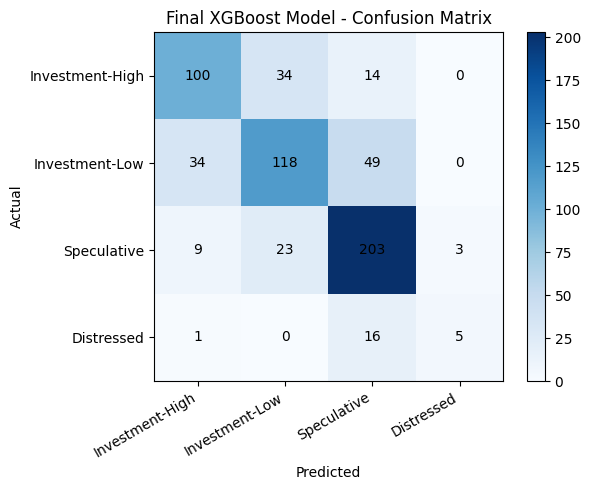

In [34]:
# Final selected XGBoost pipeline: winsorization + Optuna hyperparameters +
# num_parallel_tree=3 + tree_method="hist", max_bin=16 (Experiment 25's configuration),
# fit on the notebook's original X_train/X_test split for the final reported numbers.
final_preprocessor_selected = make_winsor_preprocessor()
final_model_params = dict(combined_params)
final_model_params.update({"num_parallel_tree": 3, "tree_method": "hist", "max_bin": 16})

final_xgboost_model = XGBClassifier(random_state=42, eval_metric="mlogloss", **final_model_params)
final_xgboost_pipeline = Pipeline(
    steps=[("preprocessor", final_preprocessor_selected), ("model", final_xgboost_model)]
)
final_xgboost_pipeline.fit(X_train, y_train)

final_xgboost_pred = final_xgboost_pipeline.predict(X_test)
final_xgboost_pred_labels = label_encoder.inverse_transform(final_xgboost_pred.astype(int))
final_xgboost_metrics = evaluate_predictions(y_test_labels, final_xgboost_pred_labels, CLASS_ORDER)

print("Final XGBoost model parameters:")
print(final_model_params)
print()
print(f"Accuracy (this split): {final_xgboost_metrics['accuracy']:.4f}")
print(f"Macro F1 (this split): {final_xgboost_metrics['macro_f1']:.4f}")
print()
print(final_xgboost_metrics["classification_report_text"])

cm = np.array(final_xgboost_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Final XGBoost Model - Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Explainable AI: SHAP Feature Importance

This section explains the final XGBoost model trained using hyperparameter tuning only in Experiment 7. Min-Max normalization is not included in the final SHAP analysis.

SHAP configuration confirmed:
Model: XGBoost
Configuration: Final Selected Model (winsorization + Optuna + num_parallel_tree=3 + hist/max_bin=16)
Preprocessing: No Min-Max normalization
Model parameters: {'n_estimators': 324, 'max_depth': 8, 'learning_rate': 0.08110932021587948, 'subsample': 0.8212663057499048, 'colsample_bytree': 0.6684815593910434, 'min_child_weight': 1, 'gamma': 0.009096143390093125, 'reg_lambda': 0.5098610905755356, 'num_parallel_tree': 3, 'tree_method': 'hist', 'max_bin': 16}

Number of records used for SHAP: 100
Number of transformed features: 37


SHAP output shape: (100, 37, 4)
Top SHAP features:


,Feature,Mean Absolute SHAP Value,Rank
0,operatingCashFlowPerShare,0.372729,1
1,netProfitMargin,0.300202,2
2,enterpriseValueMultiple,0.246393,3
3,operatingCashFlowSalesRatio,0.219934,4
4,debtRatio,0.208766,5
5,returnOnCapitalEmployed,0.200411,6
6,returnOnAssets,0.181303,7
7,fixedAssetTurnover,0.173820,8
8,payablesTurnover,0.173542,9
9,pretaxProfitMargin,0.172026,10


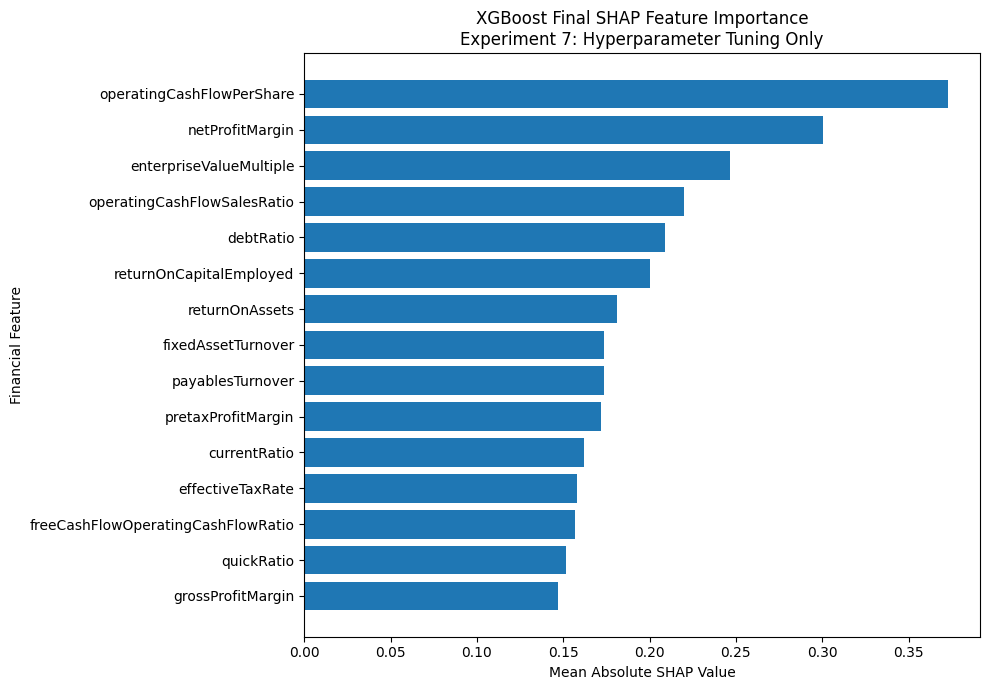

In [35]:
# ============================================================
# Final XGBoost SHAP Feature Importance
# Uses the Final Selected XGBoost Model (winsorization + Optuna hyperparameters +
# num_parallel_tree=3 + tree_method="hist", max_bin=16 - see "Final Selected XGBoost Model" above)
# Min-Max normalization is NOT used
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import MinMaxScaler


# ------------------------------------------------------------
# 1. Check that the Experiment 7 pipeline was preserved
# ------------------------------------------------------------

if "final_xgboost_pipeline" not in globals():
    raise NameError(
        "final_xgboost_pipeline was not found. "
        "Run the Final Selected XGBoost Model cell above before running SHAP."
    )


# Use only the fitted final XGBoost pipeline
final_pipeline = final_xgboost_pipeline


# ------------------------------------------------------------
# 2. Confirm that Min-Max normalization is not included
# ------------------------------------------------------------

contains_minmax = any(
    isinstance(component, MinMaxScaler)
    for component in final_pipeline.get_params(deep=True).values()
)

assert not contains_minmax, (
    "MinMaxScaler was detected. "
    "SHAP must use the final XGBoost pipeline without Min-Max normalization."
)

print("SHAP configuration confirmed:")
print("Model: XGBoost")
print("Configuration: Final Selected Model (winsorization + Optuna + num_parallel_tree=3 + hist/max_bin=16)")
print("Preprocessing: No Min-Max normalization")
print("Model parameters:", final_model_params)


# ------------------------------------------------------------
# 3. Extract the fitted preprocessor and XGBoost model
# ------------------------------------------------------------

final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]


# ------------------------------------------------------------
# 4. Apply the fitted preprocessing steps
# ------------------------------------------------------------

X_train_transformed = final_preprocessor.transform(X_train)
X_test_transformed = final_preprocessor.transform(X_test)


# Convert sparse matrices to NumPy arrays when required
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


# ------------------------------------------------------------
# 5. Obtain the transformed feature names
# ------------------------------------------------------------

feature_names = final_preprocessor.get_feature_names_out()

# Remove prefixes such as num__ and cat__
display_feature_names = np.array(
    [
        str(feature_name).split("__", 1)[-1]
        for feature_name in feature_names
    ]
)


# Confirm that the feature count matches
if X_test_transformed.shape[1] != len(display_feature_names):
    raise ValueError(
        "The number of transformed features does not match "
        "the number of feature names."
    )


# ------------------------------------------------------------
# 6. Select a sample for SHAP analysis
# ------------------------------------------------------------

# Use up to 100 test records to reduce processing time
explanation_size = min(100, X_test_transformed.shape[0])
explanation_data = X_test_transformed[:explanation_size]

print()
print("Number of records used for SHAP:", explanation_size)
print("Number of transformed features:", len(display_feature_names))


# ------------------------------------------------------------
# 7. Calculate SHAP values
# ------------------------------------------------------------

shap_explainer = shap.TreeExplainer(final_model)
shap_result = shap_explainer(explanation_data)


# Support different SHAP output formats
if isinstance(shap_result, list):
    shap_array = np.stack(
        [
            np.asarray(class_values)
            for class_values in shap_result
        ],
        axis=-1
    )

elif hasattr(shap_result, "values"):
    shap_array = np.asarray(shap_result.values)

else:
    shap_array = np.asarray(shap_result)


print("SHAP output shape:", shap_array.shape)


# ------------------------------------------------------------
# 8. Calculate mean absolute SHAP values
# ------------------------------------------------------------

if shap_array.ndim == 2:
    # Shape: observations × features
    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=0
    )

elif shap_array.ndim == 3:

    if shap_array.shape[1] == len(display_feature_names):
        # Shape: observations × features × classes
        mean_abs_shap = np.mean(
            np.abs(shap_array),
            axis=(0, 2)
        )

    elif shap_array.shape[2] == len(display_feature_names):
        # Shape: observations × classes × features
        mean_abs_shap = np.mean(
            np.abs(shap_array),
            axis=(0, 1)
        )

    elif shap_array.shape[0] == len(display_feature_names):
        # Alternative shape: features × observations × classes
        mean_abs_shap = np.mean(
            np.abs(shap_array),
            axis=(1, 2)
        )

    else:
        raise ValueError(
            "Unable to identify the feature axis. "
            f"SHAP shape: {shap_array.shape}, "
            f"number of features: {len(display_feature_names)}"
        )

else:
    raise ValueError(
        f"Unsupported SHAP dimensions: {shap_array.ndim}"
    )


# Confirm that one SHAP value exists for every feature
if len(mean_abs_shap) != len(display_feature_names):
    raise ValueError(
        "The number of mean SHAP values does not match "
        "the number of transformed features."
    )


# ------------------------------------------------------------
# 9. Create and display the ranked SHAP importance table
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    "Feature": display_feature_names,
    "Mean Absolute SHAP Value": mean_abs_shap
})

# Sort from highest to lowest SHAP importance
shap_importance = shap_importance.sort_values(
    by="Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

# Add rank as the last column
shap_importance["Rank"] = shap_importance.index + 1

# Display values to 6 decimal places
shap_importance["Mean Absolute SHAP Value"] = (
    shap_importance["Mean Absolute SHAP Value"].round(6)
)

print("Top SHAP features:")
display(shap_importance.head(15))


# ------------------------------------------------------------
# 10. Plot the top 15 features
# ------------------------------------------------------------

top_features = shap_importance.head(15).sort_values(
    by="Mean Absolute SHAP Value",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP Value"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Financial Feature")

plt.title(
    "XGBoost Final SHAP Feature Importance\n"
    "Experiment 7: Hyperparameter Tuning Only"
)

plt.tight_layout()
plt.show()

## Final Model Comparison Across All Models

This closing table places the final XGBoost model (above) alongside Random Forest, Decision
Tree, and Logistic Regression's own already-reported tuned results from their respective
notebooks - included here for reference only. The Random Forest, Decision Tree, and Logistic
Regression notebooks, their preprocessing, and their evaluation methodology were not modified
as part of this work; their numbers are reproduced from their own Experiment 7 (or equivalent)
tuned-model output, using the same `evaluate_predictions()` function and the same
`X_train`/`X_test` split shared across all four notebooks.


In [36]:
# Final cross-model comparison table (XGBoost result computed above; RF/DT/LR figures
# reproduced from their own notebooks - not recomputed or modified here)
final_comparison_df = pd.DataFrame(
    [
        {
            "Model": "XGBoost (final: winsorized + Optuna + num_parallel_tree=3 + hist/max_bin=16)",
            "Accuracy": final_xgboost_metrics["accuracy"],
            "Macro F1": final_xgboost_metrics["macro_f1"],
        },
        {"Model": "Random Forest (tuned, own Experiment 7)", "Accuracy": 0.712644, "Macro F1": 0.576142},
        {"Model": "Decision Tree (tuned, own hyperparameter search)", "Accuracy": 0.577997, "Macro F1": 0.479271},
        {"Model": "Logistic Regression (tuned, own Experiment 8 / Min-Max)", "Accuracy": 0.479475, "Macro F1": 0.379857},
    ]
)
final_comparison_df[["Accuracy", "Macro F1"]] = final_comparison_df[["Accuracy", "Macro F1"]].round(4)

print("Final cross-model comparison (XGBoost computed in this notebook; RF/DT/LR reproduced from their own notebooks):")
print()
print(final_comparison_df.to_string(index=False))

comparison_output_path = ROOT_DIR / "outputs" / "final_model_comparison.csv"
final_comparison_df.to_csv(comparison_output_path, index=False)
print()
print(f"Saved to {comparison_output_path}")


Final cross-model comparison (XGBoost computed in this notebook; RF/DT/LR reproduced from their own notebooks):

                                                                       Model  Accuracy  Macro F1
XGBoost (final: winsorized + Optuna + num_parallel_tree=3 + hist/max_bin=16)    0.6995    0.6067
                                     Random Forest (tuned, own Experiment 7)    0.7126    0.5761
                            Decision Tree (tuned, own hyperparameter search)    0.5780    0.4793
                     Logistic Regression (tuned, own Experiment 8 / Min-Max)    0.4795    0.3799

Saved to C:\Users\24042662\Desktop\C300\CreditSight\outputs\final_model_comparison.csv


## Experiment 29: SHAP-Informed Feature Pruning (`Sector`) - tried and rejected

**Hypothesis.** The SHAP section's per-feature ranking (computed on the final selected model)
shows all 12 `Sector` one-hot dummies clustered at the very bottom of importance
(0.006-0.048), below every one of the 24 numeric ratios (lowest 0.062). On ~1,420 training
rows, 12 low-signal columns are a plausible source of overfitting - dropping the entire
`Sector` feature (all 12 dummies, since it's one categorical field) and keeping only the 24
numeric ratios was tested as a genuine pruning experiment.

**Result.** Evaluated across the same 15-split robustness harness used by Experiments 12-27
(not a single train/test split): dropping `Sector` **lost on every one of the 15 splits**,
with a lower mean accuracy (0.6656 vs 0.6796, -1.4pp), lower mean macro F1 (0.5568 vs 0.5688),
and higher split-to-split variance (accuracy std 0.0158 vs 0.0130 - also less stable).

**Why removed, and the general lesson.** Each individual `Sector` dummy's SHAP value looks
negligible because the signal is split across 12 columns - no single dummy stands out, but
collectively they carry real information the model uses (plausibly sector-specific baseline
risk levels). Low per-column SHAP importance does not imply a categorical feature is safe to
drop as a whole; the two have to be evaluated separately, which is exactly what this
experiment did. `Sector` is kept in the final configuration.


## Experiment 30: Sector Target-Encoding (vs. One-Hot) - no reliable difference

**Hypothesis.** Experiment 29 showed `Sector`'s signal is real but diluted across 12 sparse
one-hot dummies. Replacing one-hot with a single smoothed ordinal target-encoded
`SectorRiskScore` column (each sector's training-fold-only smoothed mean `RatingGroup` rank,
shrunk toward the global mean for low-count sectors) was tested to see if concentrating that
signal into one dense feature helps the model use it more effectively.

**Result.** Evaluated across the same 15-split robustness harness: mean accuracy was
essentially unchanged (0.6797 vs 0.6796 one-hot, +0.0001pp - noise), mean macro F1 nudged up
slightly (0.5712 vs 0.5688, +0.24pp), and the encoding only won on accuracy in 8 of 15 splits -
not a reliable improvement either way.

**Why not adopted.** No reliable difference from the current one-hot encoding, so there's no
justification for the added complexity (a custom encoder that must be fit per training fold to
avoid leakage, versus a standard, well-understood `OneHotEncoder`). `Sector` stays one-hot
encoded in the final configuration.


## Experiment 31: Sector-Relative Ratios - no accuracy gain, small macro F1 gain

**Hypothesis.** Rather than treating `Sector` as its own feature (Experiments 29-30), use it
as *context*: replace each numeric ratio with its value relative to that company's sector
median (`ratio - sector_median_ratio`, sector medians computed on the training fold only, no
leakage), keeping `Sector` one-hot encoded alongside as before. Financially, leverage/liquidity
norms differ a lot by industry, so a company's standing *relative to its peers* may carry more
signal than the raw absolute ratio.

**Result.** Evaluated across the same 15-split robustness harness: mean accuracy was exactly
tied with the raw-ratio baseline (0.6796 vs 0.6796), and the relative version only won on
accuracy in 6 of 15 splits - worse than a coin flip. Mean macro F1 did move more than
Experiment 30's target-encoding attempt (0.5782 vs 0.5688 baseline, +0.94pp).

**Why not adopted for the accuracy-optimized final model.** No accuracy improvement, and the
macro F1 gain, while the largest seen from any Sector-related engineering attempt, is not
large enough on its own to justify replacing every numeric feature with a sector-relative
version (it changes what every single ratio *means*, a much bigger change in kind than
Experiments 29-30). Worth reconsidering only if a future iteration of this model explicitly
optimizes for Distressed-class recall over accuracy - see the Final Selected XGBoost Model
section's own note on this same accuracy/macro-F1 tradeoff.

**Pattern across Experiments 29-31, worth stating plainly:** three different ways of using
`Sector` more heavily (drop it, encode it densely, use it as relative context) all told the
same story - `Sector`-related engineering can move macro F1 a little, but does nothing for
accuracy on this dataset. This is useful negative evidence in itself: it suggests the
model's accuracy ceiling here is set by the numeric ratios and search space already explored
in Experiments 1-28, not by how `Sector` is represented.


## Experiment 32: Ordinal Regression Reformulation - decisively rejected

**Hypothesis.** `RatingGroup` has a real order (Investment-High > Investment-Low >
Speculative > Distressed), but the model treats it as four unordered classes via multiclass
softmax, which can't distinguish "predicted one band off" from "predicted the opposite end of
the scale." The final confusion matrix's dominant errors are exactly adjacent-class confusions
(Investment-High vs Investment-Low, Investment-Low vs Speculative). Reformulating as ordinal
regression - `XGBRegressor` predicting a continuous rank (0-3), rounded and clipped to the
nearest class - was tested to see if respecting that order directly reduces those errors.

**Result.** Evaluated across the same 15-split robustness harness, same final hyperparameters
and winsorized preprocessing: ordinal regression **lost on every one of the 15 splits, on
both metrics** - mean accuracy fell from 0.6796 to 0.6220 (-5.76pp), mean macro F1 fell from
0.5688 to 0.4999 (-6.89pp). This is the most decisive rejection of any experiment in this
notebook - not a tie or a marginal loss, but a consistent, substantial regression on every
split.

**Why it failed.** A naive round-to-nearest-integer regression discards the class-probability
structure the softmax objective explicitly optimizes for. With Distressed only ~3.5% of the
training data, the regressor's fitted values cluster toward the dense middle of the rank
scale (Investment-Low/Speculative) and rarely predict close enough to rank 3 to round there -
effectively under-predicting the minority class even more than the multiclass model does. This
does not rule out ordinal modeling in general: a proper cumulative-link/proportional-odds
formulation (not available natively in XGBoost, would need a dedicated library such as `mord`
or a custom loss) might behave very differently, but that is a substantially larger, riskier
build with an unproven payoff, not a quick follow-up test.
